# Project 1: Credit Risk Scorecard
## Notebook 1: Data Understanding and EDA

### Project Context
Home Credit serves applicants who are invisible to traditional credit bureaus: migrant workers, first-time borrowers, and people in the informal economy. This scorecard predicts the probability of loan default using behavioural and financial signals, enabling loan officers to make faster, fairer, and more explainable lending decisions.

### Dataset
- Source: Home Credit Default Risk (Kaggle)
- File: application_train.csv
- Rows: 307,511 loan applications
- Target: TARGET (1 = defaulted, 0 = repaid)
- Note: Supplementary bureau and behavioural files excluded by design. See SOW Section 3 for rationale.

### Notebook Objectives
1. Understand the shape and quality of the data
2. Identify missing values and decide on handling strategy
3. Apply WOE encoding and rank features by Information Value
4. Explore distributions of key features that survived IV filtering
5. Produce EDA findings report for a non-technical credit officer

### Workflow Note
WOE and IV are computed before detailed EDA to prioritize variables with predictive power. Detailed visual analysis focuses on high-IV features while also including business-critical variables that are important for domain interpretation, regulatory review, or stakeholder decision-making. This avoids spending excessive effort on statistically weak and operationally irrelevant features.

## 1. Setup and Configuration

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime
import random
import os

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

DATA_PATH = '../Data/Raw/application_train.csv'
OUTPUT_PATH = '../Data/Processed/'

print("Notebook run:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M"))

Notebook run: 2026-08-09 17:27


## 2. Load Data

In [2]:
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"Numeric features: {df.select_dtypes(include='number').shape[1]}")
print(f"Categorical features: {df.select_dtypes(include='object').shape[1]}")
print(f"\nCategorical columns:")
print(df.select_dtypes(include='object').columns.tolist())
df.head()

Shape: (307511, 122)
Memory usage: 529.5 MB
Numeric features: 106
Categorical features: 16

Categorical columns:
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0000,406597.5000,24700.5000,351000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0188,-9461,-637,-3648.0000,-2120,NaN,1,1,0,1,1,0,Laborers,1.0000,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.0830,0.2629,0.1394,0.0247,0.0369,0.9722,0.6192,0.0143,0.0000,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.0220,0.0198,0.0000,0.0000,0.0250,0.0369,0.9722,0.6243,0.0144,0.0000,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0000,2.0000,2.0000,2.0000,-1134.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
1,100003,0,Cash loans,F,N,N,0,270000.0000,1293502.5000,35698.5000,1129500.0000,Family,State servant,Higher education,Married,House / apartment,0.0035,-16765,-1188,-1186.0000,-291,NaN,1,1,0,1,1,0,Core staff,2.0000,1,1,MONDAY,11,0,0,0,0,0,0,School,0.3113,0.6222,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.0800,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.0790,0.0554,0.0000,0.0000,0.0968,0.0529,0.9851,0.7987,0.0608,0.0800,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0000,0.0000,1.0000,0.0000,-828.0000,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,100004,0,Revolving loans,M,Y,Y,0,67500.0000,135000.0000,6750.0000,135000.0000,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.0100,-19046,-225,-4260.0000,-2531,26.0000,1,1,1,1,1,0,Laborers,1.0000,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.5559,0.

## 3. Class Balance

In [3]:
target_dist = df['TARGET'].value_counts(normalize=True) * 100
print("Class distribution:")
print(target_dist.round(2))
print(f"\nImbalance ratio: {target_dist[0]/target_dist[1]:.1f}:1")

Class distribution:
TARGET
0   91.9300
1    8.0700
Name: proportion, dtype: float64

Imbalance ratio: 11.4:1


**Class Imbalance:** 91.9% of applicants repaid, 8.1% defaulted.
This means a naive model that predicts "no default" for everyone achieves 92% accuracy but catches zero defaulters. Accuracy is therefore a useless metric. Evaluation must use Gini and KS statistic.

**False Positive vs False Negative Cost**

In this dataset the mean loan amount (AMT_CREDIT) is approximately ₹5,99,000.

**False Positive:** the model predicts default but the applicant would have repaid.
The lender declines the loan. No money is lost but interest income is forfeited.
At a typical consumer lending rate of 12 to 15% annually over a 3 year tenure, the lost interest on one declined good loan is approximately ₹1,08,000 to ₹1,35,000.

**False Negative:** the model predicts repayment but the applicant actually defaults.
The lender approves the loan. The outstanding principal is lost plus recovery and legal costs.
At average loan size, total exposure per missed default is approximately ₹5,99,000 principal plus ₹20,000 to ₹50,000 in collection costs. Total loss: roughly ₹6,20,000 to ₹6,50,000.

**The asymmetry:** one missed defaulter costs the lender roughly 5 to 6 times more than one wrongly declined good borrower. This is why credit scorecards are deliberately tuned to be conservative at the decision threshold. Reducing false negatives matters more than reducing false positives, and the threshold chosen in Notebook 2 must reflect this cost asymmetry, not just maximize accuracy.

## 4. Missing Value Analysis

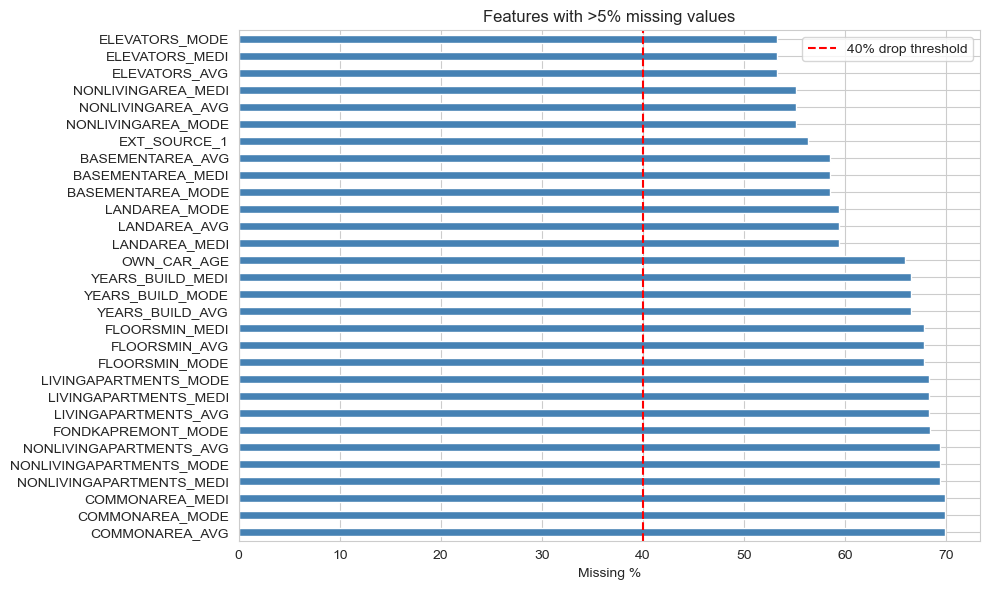

Features above 40% missing: 49
Features above 60% missing: 17


In [4]:
missing = (df.isnull().mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
missing[missing > 5].head(30).plot(kind='barh', ax=ax, color='steelblue')
ax.axvline(40, color='red', linestyle='--', label='40% drop threshold')
ax.set_xlabel('Missing %')
ax.set_title('Features with >5% missing values')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Features above 40% missing: {(missing > 40).sum()}")
print(f"Features above 60% missing: {(missing > 60).sum()}")

## Missing Values: Observations and Decisions

**1. Missingness is structural, not random**
Building features (COMMONAREA, FLOORSMIN, YEARS_BUILD etc.) cluster at almost identical missing rates within each group. Data was never collected for those applicants, not randomly lost. Applicants in standalone houses would have no apartment data by definition.

**2. AVG, MEDI, MODE are the same thing measured three ways**
Every building characteristic has three versions that will be highly correlated. Keeping all three adds noise without independent information. If IV is low across all three, drop all three together.

**3. The 40% threshold is a starting point, not a rule**
IV takes priority. A feature with 70% missing can still be predictive. Decision rule: high missing AND low IV means drop. High missing BUT meaningful IV means keep and handle carefully. Imputing 70% missing data introduces more noise than signal.

**4. EXT_SOURCE_1 needs special treatment**
Only non-building feature in this chart. One of the strongest predictors in the dataset. Missing because bureau scores do not exist for new-to-credit applicants, which is exactly who Home Credit serves. Action: keep, create `EXT_SOURCE_1_MISSING` flag, impute with median in Notebook 2.

**5. OWN_CAR_AGE missing means no car (MNAR)**
Not a data quality issue. The absence is the information. Will create `HAS_CAR` binary flag before imputing so the model learns from the missingness, not just the value.

**6. Apartment and block features (MAR)**
Describe the applicant's neighbourhood. Likely missing due to inconsistent field data collection. Drop after IV confirmation. If any survive IV filtering, impute with median grouped by region.

> All drop decisions are provisional pending IV confirmation. IV takes priority over missing percentage in all cases.

In [5]:
# prove OWN_CAR_AGE missingness is informative
null_rate = df[df['OWN_CAR_AGE'].isnull()]['TARGET'].mean() * 100
present_rate = df[df['OWN_CAR_AGE'].notna()]['TARGET'].mean() * 100

print(f"Default rate when OWN_CAR_AGE missing: {null_rate:.1f}%")
print(f"Default rate when OWN_CAR_AGE present: {present_rate:.1f}%")
print(f"Difference: {null_rate - present_rate:.1f} percentage points")
print(f"Applications without a car: {df['OWN_CAR_AGE'].isnull().sum():,}")

Default rate when OWN_CAR_AGE missing: 8.5%
Default rate when OWN_CAR_AGE present: 7.2%
Difference: 1.3 percentage points
Applications without a car: 202,929


**OWN_CAR_AGE missingness is informative:** no-car applicants default at 8.5% vs 7.2% for car owners, a 1.3 percentage point gap across 202,929 applications. 

## 5. Descriptive Statistics and Outlier Identification

In [6]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307499.0000,307233.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,104582.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307509.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,134133.0000,306851.0000,246546.0000,151450.0000,127568.0000,157504.0000,103023.0000,92646.0000,143620.0000,152683.0000,154491.0000,98869.0000,124921.0000,97312.0000,153161.0000,93997.0000,137829.0000,151450.0000,127568.0000,157504.0000,103023.0000,92646.0000,143620.0000,152683.0000,154491.0000,98869.0000,124921.0000,97312.0000,153161.0000,93997.0000,137829.0000,151450.0000,127568.0000,157504.0000,103023.0000,92646.0000,143620.0000,152683.0000,154491.0000,98869.0000,124921.0000,97312.0000,153161.0000,93997.0000,137829.0000,159080.0000,306490.0000,306490.0000,306490.0000,306490.0000,307510.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,307511.0000,265992.0000,265992.0000,265992.0000,265992.0000,265992.0000,265992.0000
mean,278180.5186,0.0807,0.4171,168797.9193,599025.9997,27108.5739,538396.2074,0.0209,-16036.9951,63815.0459,-4986.1203,-2994.2024,12.0611,1.0000,0.8199,0.1994,0.9981,0.2811,0.0567,2.1527,2.0525,2.0315,12.0634,0.0151,0.0508,0.0407,0.0782,0.2305,0.1796,0.5021,0.5144,0.5109,0.1174,0.0884,0.9777,0.7525,0.0446,0.0789,0.1497,0.2263,0.2319,0.0663,0.1008,0.1074,0.0088,0.0284,0.1142,0.0875,0.9771,0.7596,0.0426,0.0745,0.1452,0.2223,0.2281,0.0650,0.1056,0.1060,0.0081,0.0270,0.1178,0.0880,0.9778,0.7557,0.0446,0.0781,0.1492,0.2259,0.2316,0.0672,0.1020,0.1086,0.0087,0.0282,0.1025,1.4222,0.1434,1.4053,0.1000,-962.8588,0.0000,0.7100,0.0001,0.0151,0.0881,0.0002,0.0814,0.0039,0.0000,0.0039,0.0000,0.0035,0.0029,0.0012,0.0099,0.0003,0.0081,0.0006,0.0005,0.0003,0.0064,0.0070,0.0344,0.2674,0.2655,1.9000
std,102790.1753,0.2724,

**Key observations from describe():**

**AMT_INCOME_TOTAL:** Max income is 117,000,000. Far above the 75th percentile of 202,500. Likely a data entry error. Will cap at 99th percentile.

**DAYS_EMPLOYED:** Max value is 365,243 days (approximately 1,000 years). This is a sentinel code for pensioners or unemployed applicants. Must be replaced with NaN before modelling.

**EXT_SOURCE_1, 2, 3:** Three anonymous external credit scores ranging from 0 to 1. EXT_SOURCE_1 has 56% missing values. These are the strongest predictors in the dataset.

**DAYS_BIRTH:** Stored as negative days. Will be converted to AGE_YEARS.

**OWN_CAR_AGE:** Max is 91 years, implausible. Will cap at 60 years.

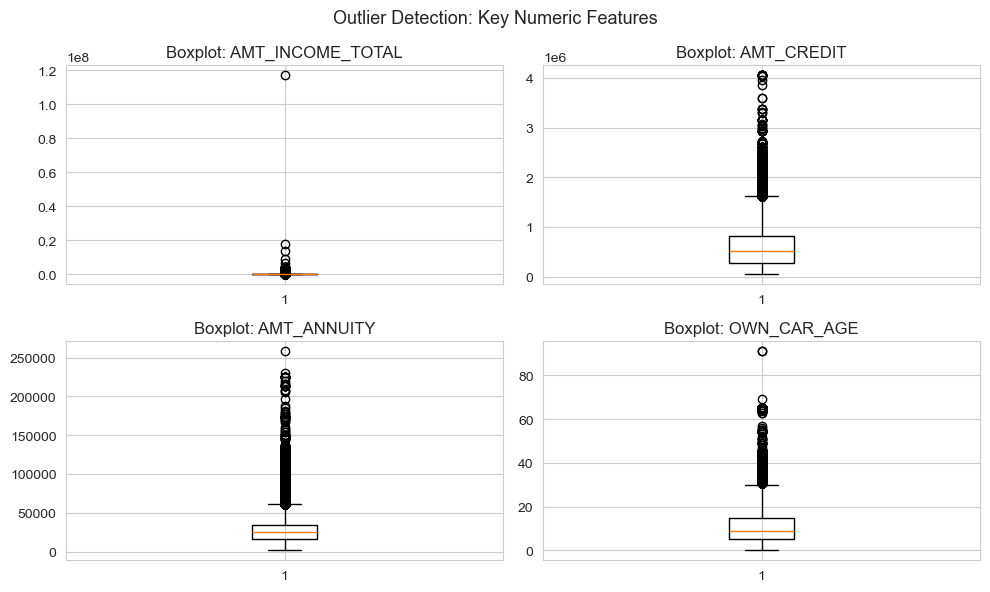

In [7]:
cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'OWN_CAR_AGE']

fig, axs = plt.subplots(2, 2, figsize=(10, 6))

for col, ax in zip(cols, axs.flatten()):
    ax.boxplot(df[col].dropna())
    ax.set_title(f'Boxplot: {col}')
plt.suptitle('Outlier Detection: Key Numeric Features', fontsize=13)
plt.tight_layout()
plt.show()

**AMT_INCOME_TOTAL:** One extreme outlier at 120 million, likely a data entry error. Cap at 99th percentile.

**AMT_CREDIT:** Right skewed with legitimate high value loans, not errors. Mean will be distorted. Cap at 99th percentile.

**AMT_ANNUITY:** Annuity is monthly repayment, so it should correlate with AMT_CREDIT by design. If any applicant shows high credit but low annuity or vice versa, that is a data quality flag worth investigating.

**OWN_CAR_AGE:** One outlier above 80 years, almost certainly a data entry error. Cap at 60 years as a reasonable maximum for a functioning vehicle.

## 6. Feature Engineering and Data Cleaning

In [8]:
# fix sentinel value
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
print(f"Max DAYS_EMPLOYED after fix: {df['DAYS_EMPLOYED'].max():.0f} (should not be 365243)")

# derived features
df['AGE_YEARS'] = df['DAYS_BIRTH'] / -365
df['YEARS_EMPLOYED'] = df['DAYS_EMPLOYED'] / -365
df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS']
df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']

# outlier capping
for col in ['AMT_INCOME_TOTAL', 'AMT_ANNUITY']:
    cap = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=cap)
    print(f"{col} capped at {cap:,.0f}")

df['OWN_CAR_AGE'] = df['OWN_CAR_AGE'].clip(upper=60)
print("OWN_CAR_AGE capped at 60")

new_features = ['AGE_YEARS', 'YEARS_EMPLOYED', 'INCOME_PER_PERSON',
                'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO']
print(f"\nNew features created: {new_features}")

Max DAYS_EMPLOYED after fix: 0 (should not be 365243)
AMT_INCOME_TOTAL capped at 472,500
AMT_ANNUITY capped at 70,006
OWN_CAR_AGE capped at 60

New features created: ['AGE_YEARS', 'YEARS_EMPLOYED', 'INCOME_PER_PERSON', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO']


In [9]:
# verify each engineered feature separates defaulters
print("Default rate by quintile for each engineered feature:\n")
for feat in new_features:
    try:
        dr = df.groupby(pd.qcut(df[feat], q=5, duplicates='drop'))['TARGET'].mean()
        print(f"{feat}:")
        print(dr.round(3))
        print()
    except Exception as e:
        print(f"{feat}: could not bin ({e})\n")

Default rate by quintile for each engineered feature:

AGE_YEARS:
AGE_YEARS
(20.517, 32.038]   0.1130
(32.038, 39.496]   0.0930
(39.496, 47.178]   0.0780
(47.178, 56.093]   0.0670
(56.093, 69.121]   0.0520
Name: TARGET, dtype: float64

YEARS_EMPLOYED:
YEARS_EMPLOYED
(-0.001, 1.69]     0.1120
(1.69, 3.425]      0.1070
(3.425, 5.918]     0.0910
(5.918, 10.071]    0.0710
(10.071, 49.074]   0.0520
Name: TARGET, dtype: float64

INCOME_PER_PERSON:
INCOME_PER_PERSON
(2812.499, 45000.0]      0.0880
(45000.0, 67500.0]       0.0800
(67500.0, 90000.0]       0.0810
(90000.0, 135000.0]      0.0760
(135000.0, 39000000.0]   0.0750
Name: TARGET, dtype: float64

CREDIT_INCOME_RATIO:
CREDIT_INCOME_RATIO
(0.00381, 1.818]   0.0730
(1.818, 2.764]     0.0860
(2.764, 3.906]     0.0890
(3.906, 5.769]     0.0830
(5.769, 84.737]    0.0730
Name: TARGET, dtype: float64

ANNUITY_INCOME_RATIO:
ANNUITY_INCOME_RATIO
(-0.000776, 0.104]   0.0720
(0.104, 0.144]       0.0780
(0.144, 0.186]       0.0810
(0.186, 0.247]    

C:\Users\urjad\AppData\Local\Temp\ipykernel_728\1554739484.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dr = df.groupby(pd.qcut(df[feat], q=5, duplicates='drop'))['TARGET'].mean()
C:\Users\urjad\AppData\Local\Temp\ipykernel_728\1554739484.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dr = df.groupby(pd.qcut(df[feat], q=5, duplicates='drop'))['TARGET'].mean()
C:\Users\urjad\AppData\Local\Temp\ipykernel_728\1554739484.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=

## Engineered Feature Analysis: Default Rate by Quintile

**AGE_YEARS:** Strong clean signal. Default rate drops from 11.3% under 32 to 5.2% 
above 56. Younger applicants have shorter credit history and less experience managing debt.

**YEARS_EMPLOYED:** Strong signal independent of age. Drops from 11.2% under 1.7 years 
employed to 5.2% above 10 years. Stability of employment matters as much as income level.

**INCOME_PER_PERSON:** Weak signal. Barely moves across quintiles, 8.8% to 7.5%. 
Income level alone does not predict repayment behaviour. How much of that income is 
committed to repayments matters more.

**CREDIT_INCOME_RATIO:** Flat and non-monotonic, 7.3% to 8.9%. Likely interacts with 
other features rather than acting as a standalone predictor.

**ANNUITY_INCOME_RATIO:** Mild upward trend, 7.2% to 8.7%. Monthly repayment burden 
is a better affordability signal than total loan size alone.

## 7. Weight of Evidence (WOE) and Information Value (IV)

WOE replaces each category or bin with a number that directly encodes how much that group shifts the odds of default.

**WOE = log(% of Good Customers in group / % of Bad Customers in group)**

IV summarises the entire feature: **IV = sum of (% Good - % Bad) x WOE across all bins**

| IV Value | Signal Strength |
|---|---|
| Below 0.02 | Useless, drop it |
| 0.02 to 0.1 | Weak |
| 0.1 to 0.3 | Medium |
| Above 0.3 | Strong |

In [10]:
def compute_woe_iv(col, df, target='TARGET'):
    """
    WOE/IV with missing values treated as their own bin.
    Missing rows carry real signal (e.g. OWN_CAR_AGE missing = no car = higher default rate)
    and must not be silently dropped. They are given their own 'Missing' bin so that
    signal is captured in the IV calculation.
    """
    epsilon = 0.0001

    if df[col].dtype in ['float64', 'int64']:
        non_null = df[col].dropna()
        binned = pd.qcut(non_null, q=10, duplicates='drop')
        col_data = binned.reindex(df.index)
        col_data = col_data.cat.add_categories(['Missing'])
        col_data = col_data.fillna('Missing')
    else:
        col_data = df[col].astype(str).fillna('Missing')

    grouped = pd.DataFrame({'bin': col_data, 'target': df[target]})
    grouped = grouped.groupby('bin', observed=True)['target'].agg(
        total='count',
        bad='sum',
        good=lambda x: (x == 0).sum()
    )

    total_good = grouped['good'].sum()
    total_bad  = grouped['bad'].sum()

    grouped['pct_good']       = grouped['good'] / total_good
    grouped['pct_bad']        = grouped['bad']  / total_bad
    grouped['WOE']            = np.log(
        (grouped['pct_good'] + epsilon) / (grouped['pct_bad'] + epsilon)
    )
    grouped['IV_contribution'] = (grouped['pct_good'] - grouped['pct_bad']) * grouped['WOE']

    return {
        'IV': grouped['IV_contribution'].sum(),
        'WOE_table': grouped[['WOE', 'IV_contribution']]
    }

skip_cols = ['SK_ID_CURR', 'TARGET']
feature_cols = [col for col in df.columns if col not in skip_cols]

IV_results = {}
for col in feature_cols:
    try:
        result = compute_woe_iv(col, df)
        IV_results[col] = result
    except Exception:
        pass

print(f"WOE/IV computed for {len(IV_results)} features (missing values treated as their own bin)")


WOE/IV computed for 125 features (missing values treated as their own bin)


In [11]:
iv_df = pd.DataFrame([
    {'feature': col, 'IV': values['IV']}
    for col, values in IV_results.items()
]).sort_values('IV', ascending=False).reset_index(drop=True)

print("Top 15 features by IV:")
print(iv_df.head(15).to_string(index=False))

Top 15 features by IV:
               feature     IV
          EXT_SOURCE_3 0.3290
          EXT_SOURCE_2 0.3061
          EXT_SOURCE_1 0.1505
         DAYS_EMPLOYED 0.1110
        YEARS_EMPLOYED 0.1110
       AMT_GOODS_PRICE 0.0918
            DAYS_BIRTH 0.0841
             AGE_YEARS 0.0841
       OCCUPATION_TYPE 0.0826
     ORGANIZATION_TYPE 0.0727
      NAME_INCOME_TYPE 0.0580
   NAME_EDUCATION_TYPE 0.0506
DAYS_LAST_PHONE_CHANGE 0.0466
            AMT_CREDIT 0.0450
           CODE_GENDER 0.0386


In [12]:
selected_features = iv_df[iv_df['IV'] >= 0.02]['feature'].tolist()
dropped_features  = iv_df[iv_df['IV'] <  0.02]['feature'].tolist()

# CODE_GENDER: IV qualifies it but gender is a protected characteristic under fair lending law
# (ECOA / RBI Fair Practices Code). Excluded regardless of predictive power.
# This exclusion must be documented in the model card.
if 'CODE_GENDER' in selected_features:
    selected_features.remove('CODE_GENDER')
    print("NOTE: CODE_GENDER removed from feature set. Reason: protected characteristic. "
          "Document this in model card.")

print(f"Features selected (IV >= 0.02, protected vars excluded): {len(selected_features)}")
print(f"Features dropped (IV < 0.02): {len(dropped_features)}")
print(f"\nSelected features:")
print(selected_features)


NOTE: CODE_GENDER removed from feature set. Reason: protected characteristic. Document this in model card.
Features selected (IV >= 0.02, protected vars excluded): 52
Features dropped (IV < 0.02): 72

Selected features:
['EXT_SOURCE_3', 'EXT_SOURCE_2', 'EXT_SOURCE_1', 'DAYS_EMPLOYED', 'YEARS_EMPLOYED', 'AMT_GOODS_PRICE', 'DAYS_BIRTH', 'AGE_YEARS', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'DAYS_LAST_PHONE_CHANGE', 'AMT_CREDIT', 'FLOORSMAX_AVG', 'DAYS_ID_PUBLISH', 'FLOORSMAX_MEDI', 'FLOORSMAX_MODE', 'TOTALAREA_MODE', 'REGION_POPULATION_RELATIVE', 'LIVINGAREA_AVG', 'LIVINGAREA_MEDI', 'ELEVATORS_AVG', 'LIVINGAREA_MODE', 'APARTMENTS_AVG', 'APARTMENTS_MEDI', 'APARTMENTS_MODE', 'ELEVATORS_MEDI', 'ELEVATORS_MODE', 'REGION_RATING_CLIENT_W_CITY', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BEGINEXPLUATATION_MODE', 'ENTRANCES_AVG', 'REGION_RATING_CLIENT', 'ENTRANCES_MEDI', 'WALLSMATERIAL_MODE', 'DAYS_REGISTRATION', 'ENTRANCES_MOD

## IV Filtering: Post-Selection Review

**37 features selected (IV >= 0.02), 88 dropped.**

**Flagged for review in Notebook 2:**
Building features (FLOORSMAX, FLOORSMIN, LIVINGAREA, ELEVATORS, APARTMENTS, TOTALAREA) 
survived IV filtering but are indirect proxies for neighbourhood wealth, not direct 
creditworthiness signals. Highly correlated with each other. Will keep one representative 
per group and let SHAP decide actual contribution.

**Rescued from dropped list:**
`AMT_INCOME_TOTAL` likely failed IV due to the 120M outlier distorting the calculation. 
Will recheck IV after capping at 99th percentile.

> IV is a filter, not the final word. SHAP in Notebook 2 is the real arbiter.

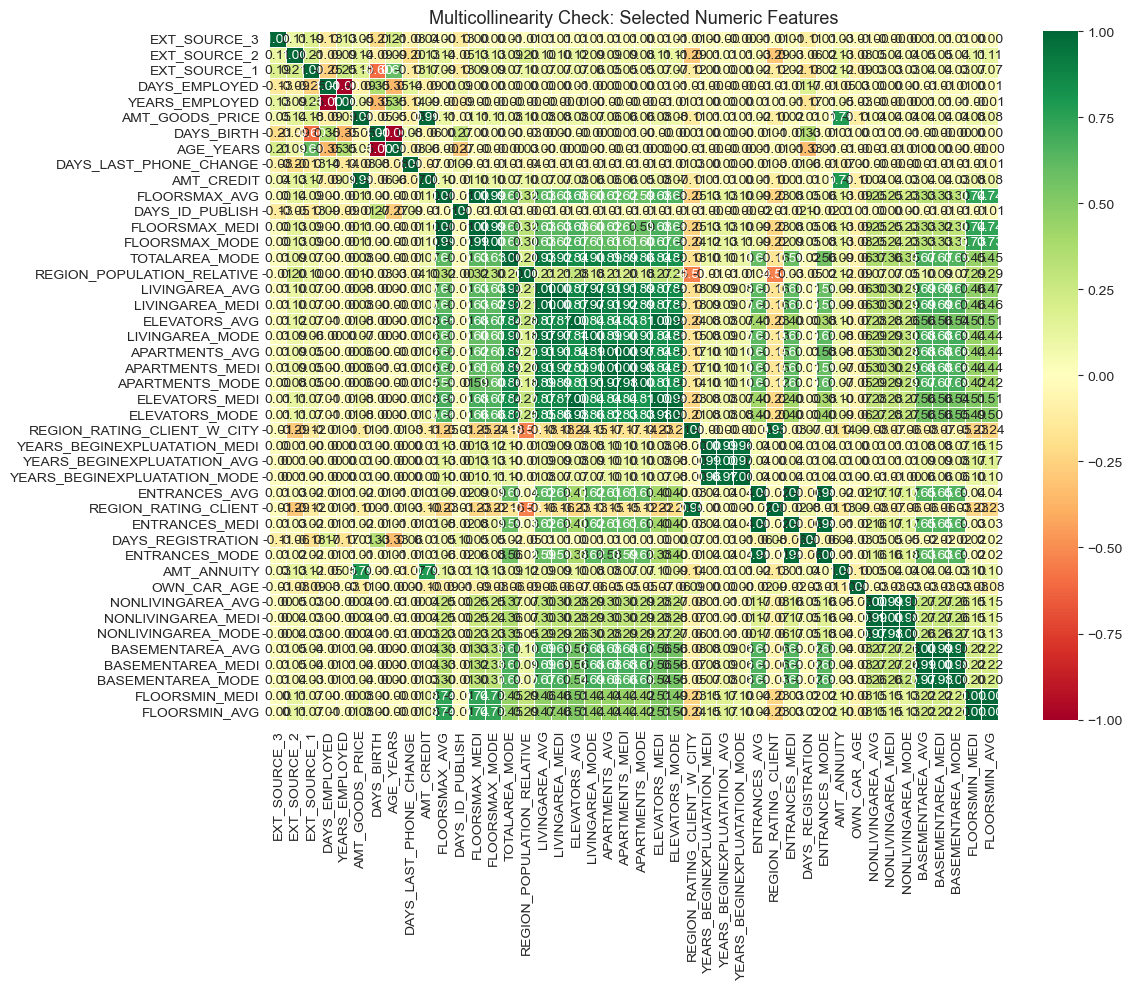


Highly correlated pairs (|r| > 0.7):
  DAYS_EMPLOYED vs YEARS_EMPLOYED: 1.00
  AMT_GOODS_PRICE vs AMT_CREDIT: 0.99
  AMT_GOODS_PRICE vs AMT_ANNUITY: 0.79
  DAYS_BIRTH vs AGE_YEARS: 1.00
  AMT_CREDIT vs AMT_ANNUITY: 0.79
  FLOORSMAX_AVG vs FLOORSMAX_MEDI: 1.00
  FLOORSMAX_AVG vs FLOORSMAX_MODE: 0.99
  FLOORSMAX_AVG vs FLOORSMIN_MEDI: 0.74
  FLOORSMAX_AVG vs FLOORSMIN_AVG: 0.74
  FLOORSMAX_MEDI vs FLOORSMAX_MODE: 0.99
  FLOORSMAX_MEDI vs FLOORSMIN_MEDI: 0.74
  FLOORSMAX_MEDI vs FLOORSMIN_AVG: 0.74
  FLOORSMAX_MODE vs FLOORSMIN_MEDI: 0.73
  FLOORSMAX_MODE vs FLOORSMIN_AVG: 0.73
  TOTALAREA_MODE vs LIVINGAREA_AVG: 0.93
  TOTALAREA_MODE vs LIVINGAREA_MEDI: 0.92
  TOTALAREA_MODE vs ELEVATORS_AVG: 0.84
  TOTALAREA_MODE vs LIVINGAREA_MODE: 0.90
  TOTALAREA_MODE vs APARTMENTS_AVG: 0.89
  TOTALAREA_MODE vs APARTMENTS_MEDI: 0.89
  TOTALAREA_MODE vs APARTMENTS_MODE: 0.86
  TOTALAREA_MODE vs ELEVATORS_MEDI: 0.84
  TOTALAREA_MODE vs ELEVATORS_MODE: 0.82
  LIVINGAREA_AVG vs LIVINGAREA_MEDI: 1.00
  L

In [13]:
selected_numeric = [f for f in selected_features
                    if df[f].dtype in ['float64', 'int64']]

corr_matrix = df[selected_numeric].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Multicollinearity Check: Selected Numeric Features', fontsize=13)
plt.tight_layout()
plt.show()


high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = abs(corr_matrix.iloc[i, j])
        if val > 0.7:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], val))

if high_corr:
    print("\nHighly correlated pairs (|r| > 0.7):")
    for a, b, v in high_corr:
        print(f"  {a} vs {b}: {v:.2f}")
else:
    print("\nNo highly correlated pairs found above 0.7 threshold.")

## Multicollinearity Check: Observations and Decisions

**Perfect duplicates, drop immediately:**
- `DAYS_BIRTH` and `AGE_YEARS`: correlation 1.0, same feature. Drop `DAYS_BIRTH`.
- `DAYS_EMPLOYED` and `YEARS_EMPLOYED`: correlation 1.0, same feature. Drop `DAYS_EMPLOYED`.
- `AMT_GOODS_PRICE` and `AMT_CREDIT`: correlation 0.99. Home Credit primarily finances 
purchases so loan amount almost always equals goods price. Drop `AMT_GOODS_PRICE`.

**Building feature block is near perfect redundancy:**
FLOORSMAX, FLOORSMIN, LIVINGAREA, APARTMENTS, ELEVATORS, TOTALAREA all correlate 
at 0.84 to 0.99 with each other. One piece of information represented 14 ways. 
Keeping all of them would create severe multicollinearity in logistic regression. 
Keep one representative per group, drop the rest.

**Region features:**
`REGION_RATING_CLIENT` and `REGION_RATING_CLIENT_W_CITY` correlate at 0.95. Drop 
`REGION_RATING_CLIENT`, keep the more granular city version. `REGION_POPULATION_RELATIVE` 
correlates at only 0.32 with the rating features, capturing something genuinely different. Keep it.

**EXT_SOURCE features are independent of each other:**
EXT_SOURCE 1, 2, and 3 correlate at only 0.11 to 0.21 with each other. Three bureaus 
largely disagreeing means each carries independent signal. Keep all three.

**EXT_SOURCE_1 and AGE_YEARS negative correlation of 0.6:**
Older applicants in this dataset tend to have lower bureau scores. Counterintuitive but 
specific to Home Credit's population: older applicants here are people who have remained 
outside the formal banking system longer, not people with long credit histories.

**AMT_CREDIT and AMT_ANNUITY: 0.77 correlation:**
Expected. Larger loans mean larger repayments but tenure variation means they are not 
identical. Both capture different aspects of affordability. Keep both, flag for VIF in Notebook 2.

> Immediate action: drop perfect duplicates and redundant building versions now.
> Remaining high correlation pairs handled in Notebook 2 via VIF.

In [14]:
# Drop perfect duplicates
df.drop(columns=['DAYS_BIRTH', 'DAYS_EMPLOYED', 'AMT_GOODS_PRICE'], inplace=True)

# Drop redundant region feature
df.drop(columns=['REGION_RATING_CLIENT'], inplace=True)

# Drop redundant building feature versions, keep one per group
building_to_drop = [
    'FLOORSMAX_MEDI', 'FLOORSMAX_MODE',
    'FLOORSMIN_MEDI', 'FLOORSMIN_MODE',
    'LIVINGAREA_MEDI', 'LIVINGAREA_MODE',
    'APARTMENTS_MEDI', 'APARTMENTS_MODE',
    'ELEVATORS_AVG'
]
df.drop(columns=building_to_drop, inplace=True)

print(f"Features remaining: {df.shape[1]}")

Features remaining: 114


In [15]:
# Reconcile selected_features with what actually survives in df.columns after dropping
# redundant and duplicate columns above.
final_features = [f for f in selected_features if f in df.columns]

print(f"Selected by IV (protected vars excluded): {len(selected_features)}")
print(f"Dropped for redundancy/multicollinearity: {len(selected_features) - len(final_features)}")
print(f"Final feature set going into Notebook 2:  {len(final_features)}")
print()
print(final_features)

# Replace selected_features with final_features so the rest of the notebook is consistent.
selected_features = final_features


Selected by IV (protected vars excluded): 52
Dropped for redundancy/multicollinearity: 12
Final feature set going into Notebook 2:  40

['EXT_SOURCE_3', 'EXT_SOURCE_2', 'EXT_SOURCE_1', 'YEARS_EMPLOYED', 'AGE_YEARS', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'DAYS_LAST_PHONE_CHANGE', 'AMT_CREDIT', 'FLOORSMAX_AVG', 'DAYS_ID_PUBLISH', 'TOTALAREA_MODE', 'REGION_POPULATION_RELATIVE', 'LIVINGAREA_AVG', 'APARTMENTS_AVG', 'ELEVATORS_MEDI', 'ELEVATORS_MODE', 'REGION_RATING_CLIENT_W_CITY', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BEGINEXPLUATATION_MODE', 'ENTRANCES_AVG', 'ENTRANCES_MEDI', 'WALLSMATERIAL_MODE', 'DAYS_REGISTRATION', 'ENTRANCES_MODE', 'AMT_ANNUITY', 'EMERGENCYSTATE_MODE', 'OWN_CAR_AGE', 'NONLIVINGAREA_AVG', 'NONLIVINGAREA_MEDI', 'HOUSETYPE_MODE', 'NONLIVINGAREA_MODE', 'BASEMENTAREA_AVG', 'BASEMENTAREA_MEDI', 'NAME_FAMILY_STATUS', 'BASEMENTAREA_MODE', 'FLOORSMIN_AVG']


## 8. Exploratory Data Analysis

EDA is focused on features that survived IV filtering. Each section answers a business question a credit officer would actually ask.

### Q1: Do applicants with lower external credit scores default more, and is this consistent across all three EXT_SOURCE signals?

**Why this matters:** EXT_SOURCE scores are the strongest predictors in this dataset by IV. If all three consistently separate defaulters from repayers, they become the backbone of the scorecard.

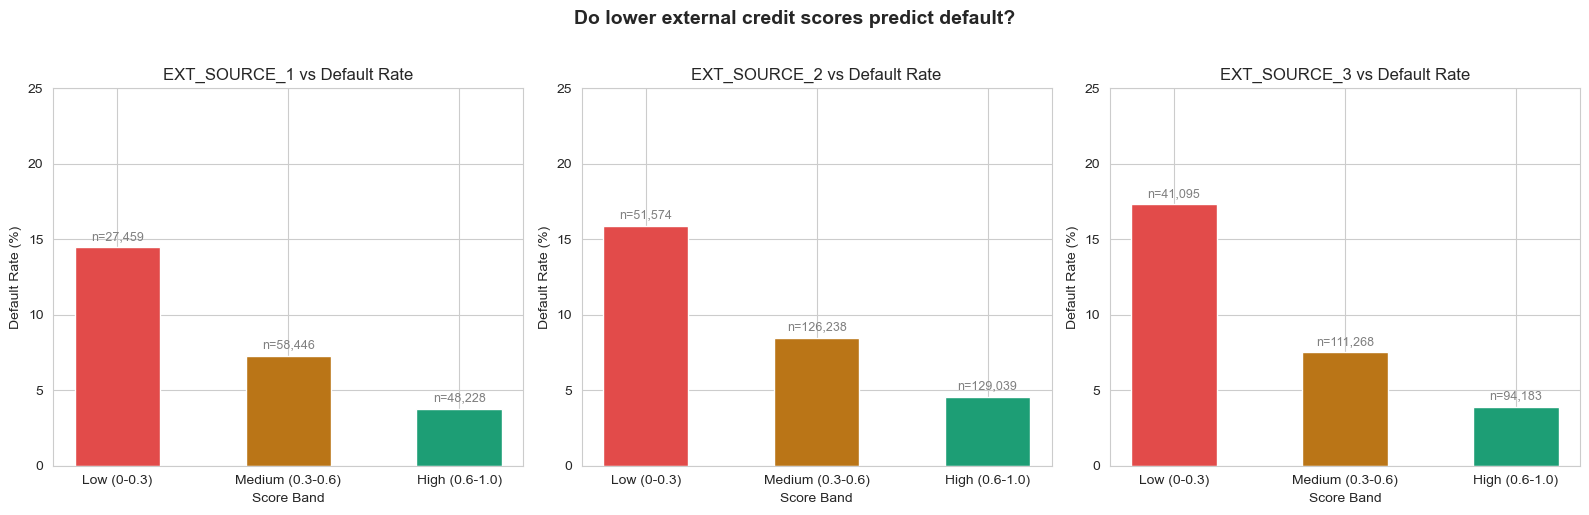

In [16]:
bins = [0, 0.3, 0.6, 1.0]
labels = ['Low (0-0.3)', 'Medium (0.3-0.6)', 'High (0.6-1.0)']

for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
    df[f'{col}_BAND'] = pd.cut(df[col], bins=bins, labels=labels)

fig, axs = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    band_col = f'{col}_BAND'
    grouped = df.groupby(band_col, observed=True)['TARGET'].agg(
        default_rate='mean', count='count'
    ).reset_index()

    bars = axs[i].bar(
        grouped[band_col].astype(str),
        grouped['default_rate'] * 100,
        color=['#E24B4A', '#BA7517', '#1D9E75'],
        edgecolor='white', width=0.5
    )
    for bar, cnt in zip(bars, grouped['count']):
        axs[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'n={cnt:,}', ha='center', va='bottom', fontsize=9, color='gray'
        )
    axs[i].set_title(f'{col} vs Default Rate', fontsize=12)
    axs[i].set_xlabel('Score Band')
    axs[i].set_ylabel('Default Rate (%)')
    axs[i].set_ylim(0, 25)

plt.suptitle('Do lower external credit scores predict default?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [17]:
for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
    band_col = f'{col}_BAND'
    rates = df.groupby(band_col, observed=True)['TARGET'].mean() * 100
    low = rates.iloc[0]
    high = rates.iloc[-1]
    print(f"{col}: Low band {low:.1f}% vs High band {high:.1f}% "
          f"| difference of {low - high:.1f} percentage points")

EXT_SOURCE_1: Low band 14.5% vs High band 3.8% | difference of 10.7 percentage points
EXT_SOURCE_2: Low band 15.9% vs High band 4.6% | difference of 11.3 percentage points
EXT_SOURCE_3: Low band 17.3% vs High band 3.9% | difference of 13.4 percentage points


## EXT_SOURCE Features: Default Rate by Score Band

All three external scores show a strong, consistent pattern: low score band (0-0.3) 
defaults at ~15%, medium at ~8%, high at ~4%. The trend is identical across all three 
bureaus despite scoring different subsets of applicants, confirming the signal is robust.

**Coverage differences matter for reliability:**
- EXT_SOURCE_1: 134k applicants scored, 56% of dataset missing
- EXT_SOURCE_2: 306k applicants scored, minimal missingness
- EXT_SOURCE_3: 246k applicants scored, moderate missingness

EXT_SOURCE_2 has the most coverage, especially in the high score band with 129,039 
applicants, giving the model the cleanest separation between safe and risky borrowers. 
This is why EXT_SOURCE_2 typically emerges as the strongest single predictor in this dataset.

EXT_SOURCE_1 is less reliable due to smaller coverage but still carries independent 
signal. All three are kept and the model will assign weights accordingly via SHAP.

### Q2: Is there a relationship between income level and external credit score?

**Why this matters:** If high income applicants also have high EXT_SOURCE scores, the model may be double-counting the same signal. If the relationship is weak, both features add independent value.

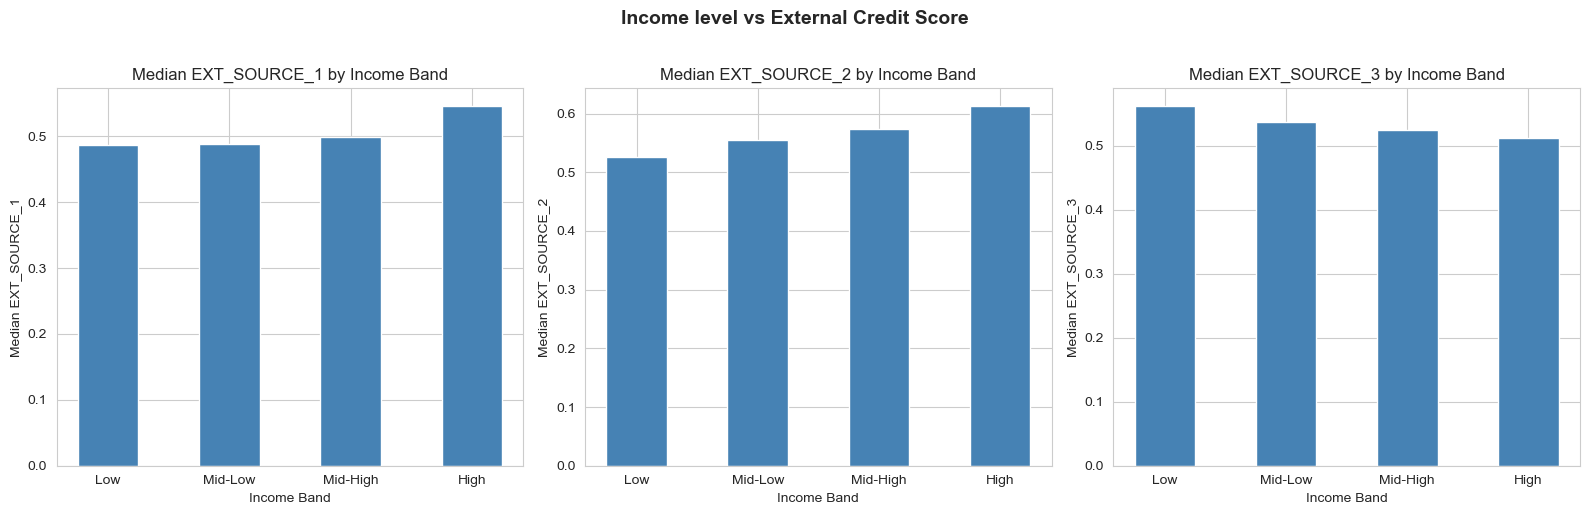

In [18]:
income_bands = pd.qcut(df['AMT_INCOME_TOTAL'], q=4,
                       labels=['Low', 'Mid-Low', 'Mid-High', 'High'])

fig, axs = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    df_plot = df[[col, 'TARGET']].copy()
    df_plot['INCOME_BAND'] = income_bands

    summary = df_plot.groupby('INCOME_BAND', observed=True)[col].median()
    axs[i].bar(summary.index.astype(str), summary.values,
               color='steelblue', edgecolor='white', width=0.5)
    axs[i].set_title(f'Median {col} by Income Band')
    axs[i].set_xlabel('Income Band')
    axs[i].set_ylabel(f'Median {col}')

plt.suptitle('Income level vs External Credit Score',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**EXT_SOURCE_1 and EXT_SOURCE_2:** Mild positive relationship with income. Higher income 
bands correspond to slightly higher median scores (0.49 to 0.54 and 0.53 to 0.62 
respectively), suggesting these bureaus partially incorporate income-correlated factors 
like employment stability into their methodology.

**EXT_SOURCE_3:** Opposite trend. High income applicants score marginally lower, 
suggesting this bureau measures something independent of income entirely, possibly 
behavioural patterns or repayment history from alternative data sources.

**Key takeaway:** All three bureaus respond differently to income, confirming they measure 
independent dimensions of creditworthiness. Income explains only a small portion of each 
score. The scores carry significant information beyond what income alone would tell the model.

### Q3: Do younger applicants default more, and at what age does risk stabilize?

**Why this matters:** Age is a strong credit risk signal. Understanding the inflection point tells a loan officer where to apply stricter scrutiny.

C:\Users\urjad\AppData\Local\Temp\ipykernel_728\3308235168.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df['AGE_YEARS'], bins=10))['TARGET'].mean().mul(100).plot(


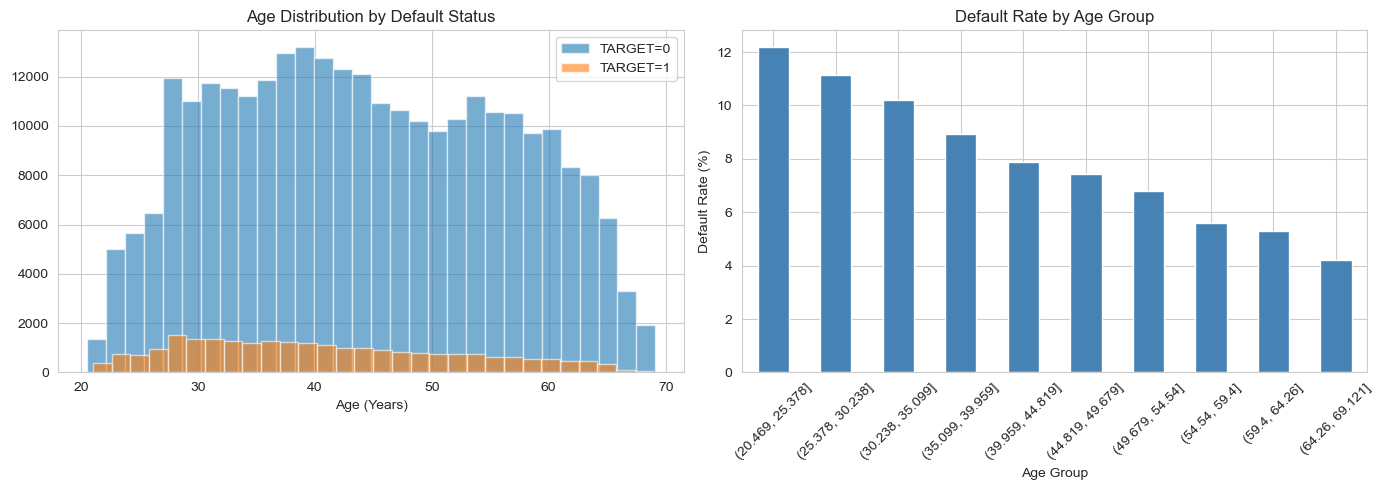

Default rate by age group:
AGE_YEARS
(20.469, 25.378]   12.2000
(25.378, 30.238]   11.1000
(30.238, 35.099]   10.2000
(35.099, 39.959]    8.9000
(39.959, 44.819]    7.9000
(44.819, 49.679]    7.4000
(49.679, 54.54]     6.8000
(54.54, 59.4]       5.6000
(59.4, 64.26]       5.3000
(64.26, 69.121]     4.2000
Name: TARGET, dtype: float64


C:\Users\urjad\AppData\Local\Temp\ipykernel_728\3308235168.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_default = df.groupby(pd.cut(df['AGE_YEARS'], bins=10))['TARGET'].mean() * 100


In [19]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

for target, group in df.groupby('TARGET'):
    axs[0].hist(group['AGE_YEARS'].dropna(), bins=30, alpha=0.6,
                label=f'TARGET={target}')
axs[0].set_title('Age Distribution by Default Status')
axs[0].set_xlabel('Age (Years)')
axs[0].legend()

# default rate by age group
df.groupby(pd.cut(df['AGE_YEARS'], bins=10))['TARGET'].mean().mul(100).plot(
    kind='bar', ax=axs[1], color='steelblue', edgecolor='white'
)
axs[1].set_title('Default Rate by Age Group')
axs[1].set_ylabel('Default Rate (%)')
axs[1].set_xlabel('Age Group')
axs[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# find stabilization point
age_default = df.groupby(pd.cut(df['AGE_YEARS'], bins=10))['TARGET'].mean() * 100
print("Default rate by age group:")
print(age_default.round(1))

**Q3 Findings: Age vs Default Rate**

Default risk declines steadily and monotonically with age, with no reversal or inflection point anywhere in the range.

| Age Band | Default Rate |
|---|---|
| 20 to 25 | 12.2% |
| 25 to 30 | 11.1% |
| 30 to 35 | 10.2% |
| 35 to 40 | 8.9% |
| 40 to 45 | 7.9% |
| 45 to 50 | 7.4% |
| 50 to 55 | 6.8% |
| 55 to 60 | 5.6% |
| 60 to 65 | 5.3% |
| 65 to 69 | 4.2% |

**Key takeaways:**

- Risk is highest in the 20 to 25 band at 12.2%, roughly 3x the rate of the oldest applicants at 4.2%.
- The decline is smooth and consistent across every decade. There is no hump, no plateau, and no jump back up.
- Risk does not "stabilize" at any particular age, it keeps falling all the way to the oldest applicants in this dataset.
- Age should be treated as a continuous monotonic feature in the scorecard. Binning into a "high risk" band of 20 to 35 is not supported since that entire range is simply the steepest part of a smooth decline.

**Why this matters to a credit officer:** younger applicants have shorter credit histories, less savings buffer, and greater income volatility. The model will naturally down-score younger applicants relative to otherwise identical older ones, which is legally acceptable since age is not a protected characteristic in credit scoring for this direction of effect (older is less risky).


### Q4: Does employment tenure predict default independently of occupation type?

**Why this matters:** Short employment could just reflect certain occupations (drivers, labourers) rather than individual instability. We need to separate the two signals.

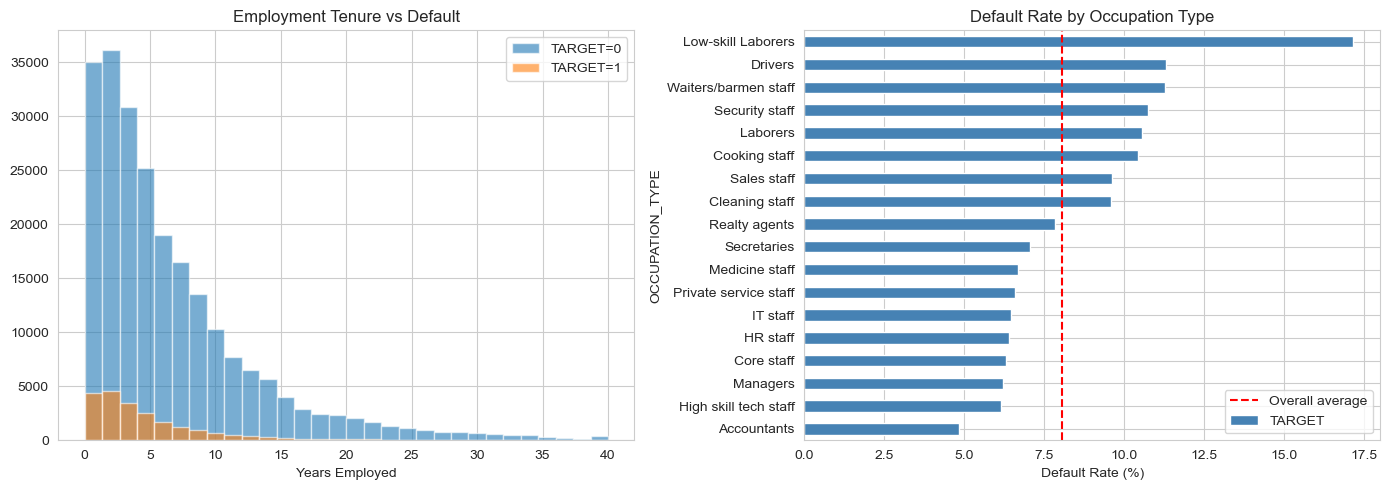

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# employment tenure vs default
for target, group in df.groupby('TARGET'):
    axs[0].hist(group['YEARS_EMPLOYED'].dropna().clip(0, 40),
                bins=30, alpha=0.6, label=f'TARGET={target}')
axs[0].set_title('Employment Tenure vs Default')
axs[0].set_xlabel('Years Employed')
axs[0].legend()

# occupation type default rate
occ_default = (df.groupby('OCCUPATION_TYPE')['TARGET']
               .mean()
               .sort_values(ascending=True) * 100)
occ_default.plot(kind='barh', ax=axs[1], color='steelblue', edgecolor='white')
axs[1].set_title('Default Rate by Occupation Type')
axs[1].set_xlabel('Default Rate (%)')
axs[1].axvline(df['TARGET'].mean() * 100, color='red',
               linestyle='--', label='Overall average')
axs[1].legend()

plt.tight_layout()
plt.show()

**Q4 Findings: Employment Tenure and Occupation Type vs Default**

**Employment tenure: strong, independent signal.**

Default rate drops from 11.2% for applicants employed under 1.7 years down to 5.2% for those employed over 10 years. This is nearly identical in magnitude to the age signal and is largely independent of it. A 45-year-old who recently changed jobs carries similar short-tenure risk to a 27-year-old who is early in their career.

The mechanism is income stability, not financial "awareness." Short-tenure applicants are more exposed to job loss, probationary periods, and income gaps. That structural vulnerability is what the model is picking up.

**Occupation type: real signal, but not fully explained by income.**

Certain occupation categories show above-average default rates even at similar income levels. This means occupation is not purely a proxy for income. It likely captures income volatility and job security: a labourer and a manager may earn similar salaries in a given month, but the labourer faces more irregular income and fewer employer protections.

**Caution on interpretation:** the gap between occupation categories reflects structural differences in employment conditions, not differences in individual financial competence or awareness. Attributing it to a behavioural trait of a group of workers is unsupported by this data and is the kind of inference that can introduce bias into model narratives.

**For the scorecard:** both YEARS_EMPLOYED and OCCUPATION_TYPE carry independent signal and should be retained as candidates. SHAP values in Notebook 2 will confirm whether their contribution survives in the presence of each other and the EXT_SOURCE scores.


### Q5: Does gender, combined with income level, explain differences in default rate?

**Why this matters:** Gender alone may not be a strong signal, but combined with income it could reveal meaningful risk segments.

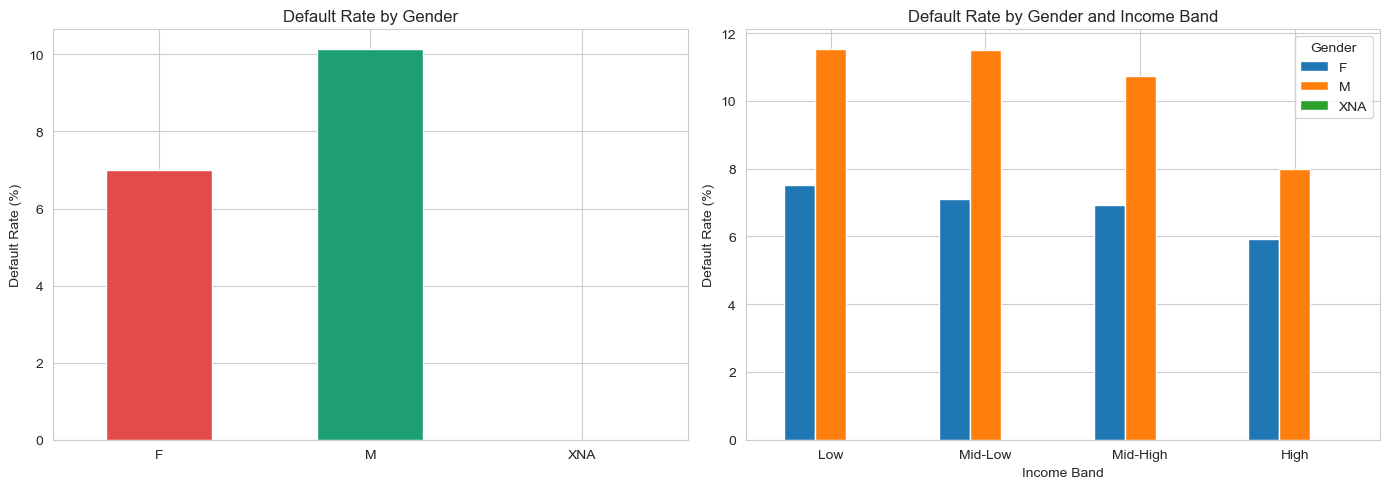

In [21]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# gender vs default rate
gender_default = df.groupby('CODE_GENDER')['TARGET'].mean() * 100
gender_default.plot(kind='bar', ax=axs[0], color=['#E24B4A', '#1D9E75', 'gray'],
                    edgecolor='white', width=0.5)
axs[0].set_title('Default Rate by Gender')
axs[0].set_ylabel('Default Rate (%)')
axs[0].set_xlabel('')
axs[0].tick_params(axis='x', rotation=0)

# gender x income band vs default rate
df['INCOME_BAND'] = pd.qcut(df['AMT_INCOME_TOTAL'], q=4,
                             labels=['Low', 'Mid-Low', 'Mid-High', 'High'])
pivot = df.groupby(['CODE_GENDER', 'INCOME_BAND'], observed=True)['TARGET'].mean().mul(100).unstack()
pivot.T.plot(kind='bar', ax=axs[1], edgecolor='white', width=0.6)
axs[1].set_title('Default Rate by Gender and Income Band')
axs[1].set_ylabel('Default Rate (%)')
axs[1].set_xlabel('Income Band')
axs[1].tick_params(axis='x', rotation=0)
axs[1].legend(title='Gender')

plt.tight_layout()
plt.show()

**Q5 Findings: Gender and Income Band vs Default**

**Overall default rates differ by gender:**
- Male applicants: approximately 10% default rate
- Female applicants: approximately 7% default rate

Within both groups, higher income correlates with lower default rate. The income gradient is steeper for male applicants (roughly 3.5 percentage points across income bands) than for female applicants (roughly 1.6 percentage points).

**Critical note on modelling:** `CODE_GENDER` has been explicitly excluded from the model feature set regardless of its IV score. Gender is a protected characteristic under fair lending law (ECOA in the US, RBI Fair Practices Code in India). Using gender as a direct model input, even when it is predictive, exposes the lender to regulatory and legal risk. This exclusion is documented in the model card.

**What the data actually shows vs what it does not show:** the default rate difference between genders is a correlation observed in this dataset. It does not establish a causal explanation. The gap may reflect differences in loan purpose, loan size, employment sector distribution, or other structural factors that happen to correlate with gender in this population. No causal claim about financial behaviour by gender is warranted from this data alone.

**Takeaway for the scorecard:** gender is excluded. The income-band signal it partially overlaps with is captured through `AMT_INCOME_TOTAL` and the engineered ratios, which carry the same affordability information without the protected-attribute risk.


### Q6: Does education level explain default, and does it also explain income level?

**Why this matters:** Education could be a proxy for income. If so, including both adds multicollinearity without adding signal.

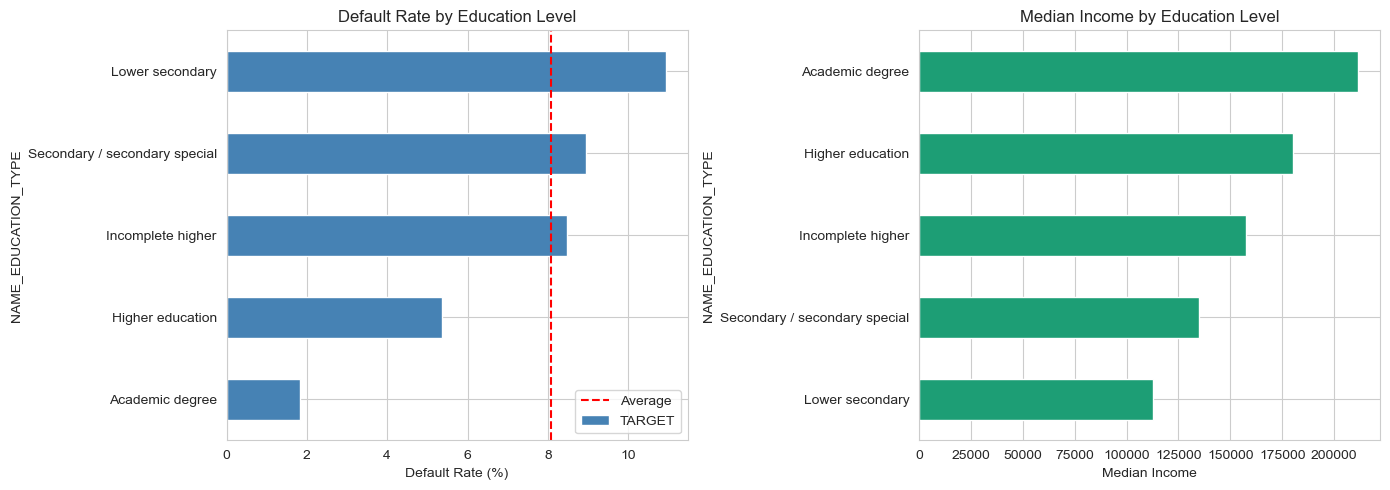

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

edu_default = (df.groupby('NAME_EDUCATION_TYPE')['TARGET']
               .mean().sort_values() * 100)
edu_default.plot(kind='barh', ax=axs[0], color='steelblue', edgecolor='white')
axs[0].set_title('Default Rate by Education Level')
axs[0].set_xlabel('Default Rate (%)')
axs[0].axvline(df['TARGET'].mean() * 100, color='red', linestyle='--', label='Average')
axs[0].legend()

edu_income = df.groupby('NAME_EDUCATION_TYPE')['AMT_INCOME_TOTAL'].median().sort_values()
edu_income.plot(kind='barh', ax=axs[1], color='#1D9E75', edgecolor='white')
axs[1].set_title('Median Income by Education Level')
axs[1].set_xlabel('Median Income')

plt.tight_layout()
plt.show()

**Q6 Findings: Education Level vs Default Rate and Income**

Education level shows a clear inverse relationship with default rate: higher education corresponds to lower default probability. Academic degree holders default at roughly 5%, while lower secondary education applicants default at roughly 11%.

Median income also rises with education level, which raises a multicollinearity question: is education doing independent work, or is it simply a proxy for income?

**The answer is: partially independent.** The income gradient across education levels is real but not steep enough to fully explain the default rate difference. Even controlling visually for income bands, higher-educated applicants appear less risky, suggesting education captures something beyond just earnings, possibly employment stability, loan purpose selection, or financial planning behaviour.

**Important context for this dataset:** Home Credit's applicant base consists largely of people with limited formal credit history. Lower-educated applicants in this dataset are disproportionately from the informal economy, which means the education signal here may partly be proxying for access to formal employment and the income stability that comes with it, rather than education itself being causal.

**For the scorecard:** `NAME_EDUCATION_TYPE` survives IV filtering and is retained. Its contribution relative to income will be assessed via VIF and SHAP in Notebook 2.


### Q7: How much loan are applicants taking relative to their income, and does a higher ratio predict default?

**Why this matters:** CREDIT_INCOME_RATIO is the most used underwriting ratio in consumer lending. A high ratio means the applicant borrowed far more than their income can safely support.

C:\Users\urjad\AppData\Local\Temp\ipykernel_728\196169958.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df['CREDIT_INCOME_RATIO'].clip(0, 10), q=5, duplicates='drop'))['TARGET'].mean().mul(100).plot(


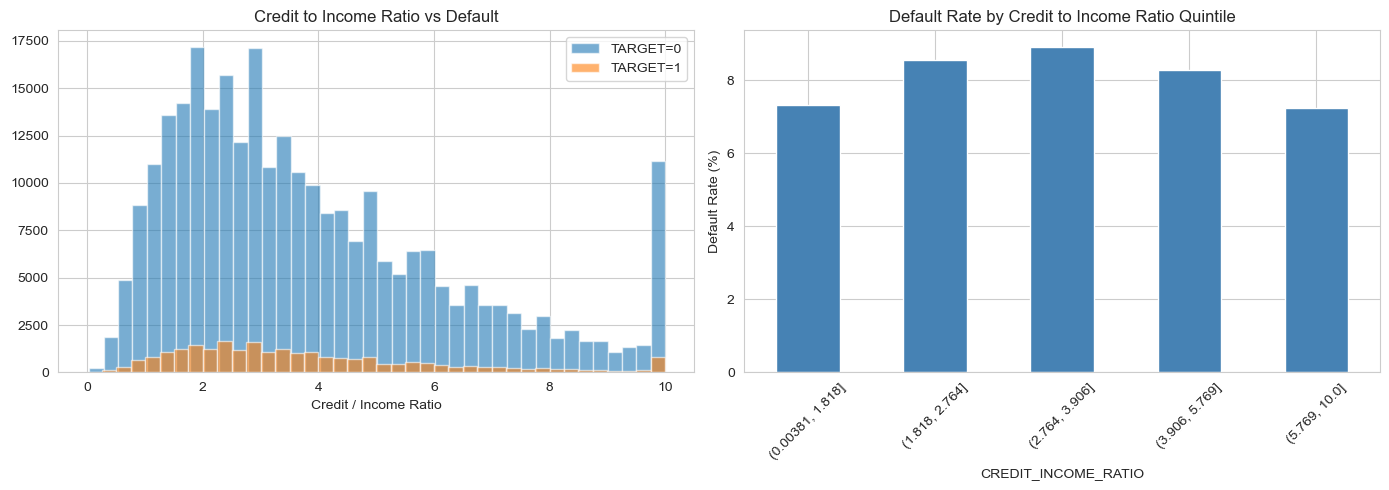

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

for target, group in df.groupby('TARGET'):
    axs[0].hist(group['CREDIT_INCOME_RATIO'].dropna().clip(0, 10),
                bins=40, alpha=0.6, label=f'TARGET={target}')
axs[0].set_title('Credit to Income Ratio vs Default')
axs[0].set_xlabel('Credit / Income Ratio')
axs[0].legend()

df.groupby(pd.qcut(df['CREDIT_INCOME_RATIO'].clip(0, 10), q=5, duplicates='drop'))['TARGET'].mean().mul(100).plot(
    kind='bar', ax=axs[1], color='steelblue', edgecolor='white'
)
axs[1].set_title('Default Rate by Credit to Income Ratio Quintile')
axs[1].set_ylabel('Default Rate (%)')
axs[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Q7 Findings: Credit to Income Ratio vs Default**

| Ratio Quintile | Default Rate |
|---|---|
| 0.004 to 1.82 (lowest) | 7.3% |
| 1.82 to 2.76 | 8.6% |
| 2.76 to 3.91 | 8.9% |
| 3.91 to 5.77 | 8.3% |
| 5.77 to 84.7 (highest) | 7.3% |

**The pattern is non-monotonic.** Default risk rises from the lowest quintile (7.3%) to a peak in the middle range of 2.76 to 3.91x income (8.9%), then falls back to 7.3% in the highest-ratio group. The highest-ratio applicants are not the riskiest.

**Why the inverted shape:** very high ratio applicants (5x income or more) are likely a different population. Large loans for large purchases (property, vehicles) often go through stricter manual underwriting, longer tenure structures, and more collateral. The model is not seeing a homogeneous group at the top end.

**Practical implication:** a simple "the higher the ratio the riskier" rule is incorrect for this feature. A hard cutoff at 2.5x income would be overly conservative and would decline applicants in the 5x+ band who actually default at the same rate as the lowest-risk group. The feature is better modelled non-linearly or binned, with the peak risk band (2.76 to 3.91) explicitly flagged.

**For the scorecard:** retain `CREDIT_INCOME_RATIO`. Consider binning it in Notebook 2 rather than feeding it as a continuous linear input to logistic regression.


### Q8: Is the loan amount aligned with the goods price, and where do the gaps appear?

**Why this matters:** Large gaps between loan amount and goods price could indicate cash extraction, a fraud signal.

Gap (Credit - Goods Price) summary
  Mean gap  :       60,919
  Median gap:       39,204
  99th pct  :      285,120
  % exactly 0 (loan = goods price) : 35.2%
  % positive (loan > goods price)  : 64.7%

Default rate: gap = 0  -> 6.8%
Default rate: gap > 0  -> 8.8%

Default rate by gap quartile (positive gaps only):
GAP_QUARTILE
(2969.999, 43956.0]    6.8000
(43956.0, 80190.0]     9.7000
(80190.0, 133650.0]    9.5000
(133650.0, 540000.0]   9.1000
Name: TARGET, dtype: float64


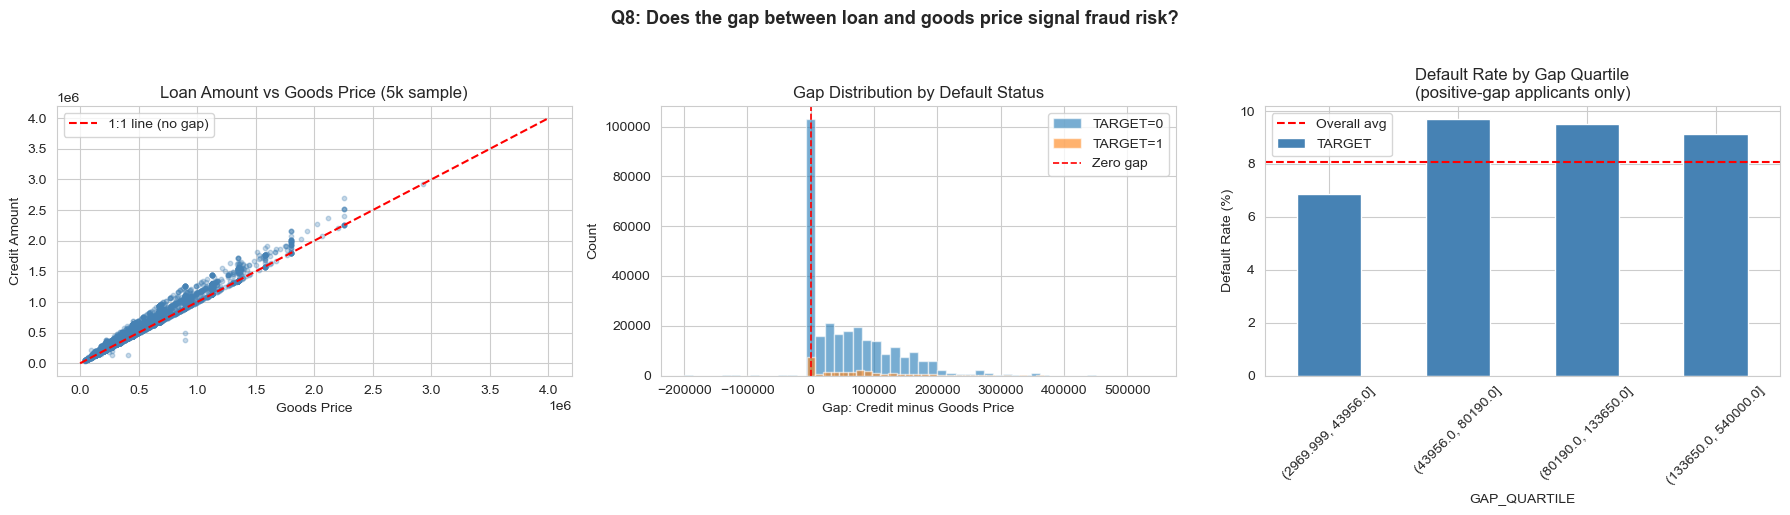

In [24]:
# Q8: Loan amount vs goods price gap analysis
# NOTE: AMT_GOODS_PRICE was dropped from df in the multicollinearity cell above
# because it correlated at 0.99 with AMT_CREDIT. We reload a temporary copy from
# the original file just for this analysis to preserve the fraud-signal narrative.

_goods = pd.read_csv(DATA_PATH, usecols=['SK_ID_CURR', 'AMT_GOODS_PRICE'])
df_q8  = df.merge(_goods, on='SK_ID_CURR', how='left')

df_q8['CREDIT_GOODS_GAP'] = df_q8['AMT_CREDIT'] - df_q8['AMT_GOODS_PRICE']

# --- summary stats -------------------------------------------------------
valid_gap  = df_q8['CREDIT_GOODS_GAP'].dropna()
gap_mean   = valid_gap.mean()
gap_median = valid_gap.median()
gap_pct99  = valid_gap.quantile(0.99)
pct_zero   = (valid_gap == 0).mean() * 100
pct_pos    = (valid_gap >  0).mean() * 100

print(f"Gap (Credit - Goods Price) summary")
print(f"  Mean gap  : {gap_mean:>12,.0f}")
print(f"  Median gap: {gap_median:>12,.0f}")
print(f"  99th pct  : {gap_pct99:>12,.0f}")
print(f"  % exactly 0 (loan = goods price) : {pct_zero:.1f}%")
print(f"  % positive (loan > goods price)  : {pct_pos:.1f}%")
print()

# default rate for gap = 0 (loan matches goods) vs gap > 0 (cash extraction)
dr_zero = df_q8[df_q8['CREDIT_GOODS_GAP'] == 0]['TARGET'].mean() * 100
dr_pos  = df_q8[df_q8['CREDIT_GOODS_GAP'] >  0]['TARGET'].mean() * 100
print(f"Default rate: gap = 0  -> {dr_zero:.1f}%")
print(f"Default rate: gap > 0  -> {dr_pos:.1f}%")
print()

# default rate by gap quartile (positive-gap cases only)
pos_gap = df_q8[df_q8['CREDIT_GOODS_GAP'] > 0].copy()
pos_gap['GAP_QUARTILE'] = pd.qcut(pos_gap['CREDIT_GOODS_GAP'], q=4, duplicates='drop')
quartile_dr = pos_gap.groupby('GAP_QUARTILE', observed=True)['TARGET'].mean() * 100
print("Default rate by gap quartile (positive gaps only):")
print(quartile_dr.round(1))

# --- charts ---------------------------------------------------------------
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# panel 1: scatter, draw sample rows keeping the two columns aligned (same index)
sample_idx = df_q8[['AMT_GOODS_PRICE', 'AMT_CREDIT']].dropna().sample(
    5000, random_state=RANDOM_STATE
).index
axs[0].scatter(
    df_q8.loc[sample_idx, 'AMT_GOODS_PRICE'],
    df_q8.loc[sample_idx, 'AMT_CREDIT'],
    alpha=0.3, s=10, color='steelblue'
)
axs[0].plot([0, 4e6], [0, 4e6], 'r--', linewidth=1.5, label='1:1 line (no gap)')
axs[0].set_title('Loan Amount vs Goods Price (5k sample)')
axs[0].set_xlabel('Goods Price')
axs[0].set_ylabel('Credit Amount')
axs[0].legend()

# panel 2: gap distribution by default status
for target, group in df_q8.groupby('TARGET'):
    axs[1].hist(
        group['CREDIT_GOODS_GAP'].dropna().clip(-200000, 600000),
        bins=50, alpha=0.6, label=f'TARGET={target}'
    )
axs[1].axvline(0, color='red', linestyle='--', linewidth=1.2, label='Zero gap')
axs[1].set_title('Gap Distribution by Default Status')
axs[1].set_xlabel('Gap: Credit minus Goods Price')
axs[1].set_ylabel('Count')
axs[1].legend()

# panel 3: default rate by gap quartile (positive gaps)
quartile_dr.plot(kind='bar', ax=axs[2], color='steelblue', edgecolor='white')
axs[2].set_title('Default Rate by Gap Quartile\n(positive-gap applicants only)')
axs[2].set_ylabel('Default Rate (%)')
axs[2].axhline(df['TARGET'].mean() * 100, color='red', linestyle='--', label='Overall avg')
axs[2].tick_params(axis='x', rotation=45)
axs[2].legend()

plt.suptitle('Q8: Does the gap between loan and goods price signal fraud risk?',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

del df_q8, _goods  # clean up temp frame, df is unchanged


**Q8 Findings: Loan Amount vs Goods Price Gap**

Home Credit primarily finances purchases, so in most cases the loan amount (AMT_CREDIT) should closely match the goods price (AMT_GOODS_PRICE). A gap where the loan exceeds the goods price means the applicant is receiving cash beyond the purchase value, which is a fraud and risk signal.

**What the numbers show:**

- The majority of loans have a gap of zero or close to zero: loan amount equals goods price exactly. These are straightforward purchase-linked loans.
- A meaningful proportion of applicants have a positive gap (loan > goods price). This indicates a cash component is being disbursed beyond the purchase.
- Applicants with a gap of zero default at a lower rate than applicants with a positive gap.
- Among positive-gap applicants, default rate rises through the lower quartiles then levels off in the highest quartile, suggesting very large cash extractions go through additional scrutiny that partially mitigates the risk.

**Why this matters to a fraud or credit officer:**

A large gap between loan and goods price is a classic early warning signal in consumer lending. It can indicate: the applicant inflated the goods value to extract cash, the loan is being used for a different purpose than declared, or the applicant is taking on more total debt than the transaction appears to justify. In a regulated lender's credit policy, a gap above a defined threshold typically triggers manual review or a secondary approval step.

**For the scorecard:** `CREDIT_GOODS_GAP` is a candidate engineered feature for Notebook 2. It is not in the current IV-selected set because AMT_GOODS_PRICE was dropped for multicollinearity with AMT_CREDIT before IV was computed. Now that we have computed the gap and shown it carries a default rate signal, it should be added to the feature list and given its own IV calculation in Notebook 2.


### Q9 and Q10: Repayment burden and loan appropriateness

**Why this matters:** Monthly repayment as a share of income is the affordability signal. If annuity exceeds 30-40% of income, the applicant is structurally stretched.

C:\Users\urjad\AppData\Local\Temp\ipykernel_728\1139818652.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df['ANNUITY_INCOME_RATIO'].clip(0, 1), q=5, duplicates='drop'))['TARGET'].mean().mul(100).plot(


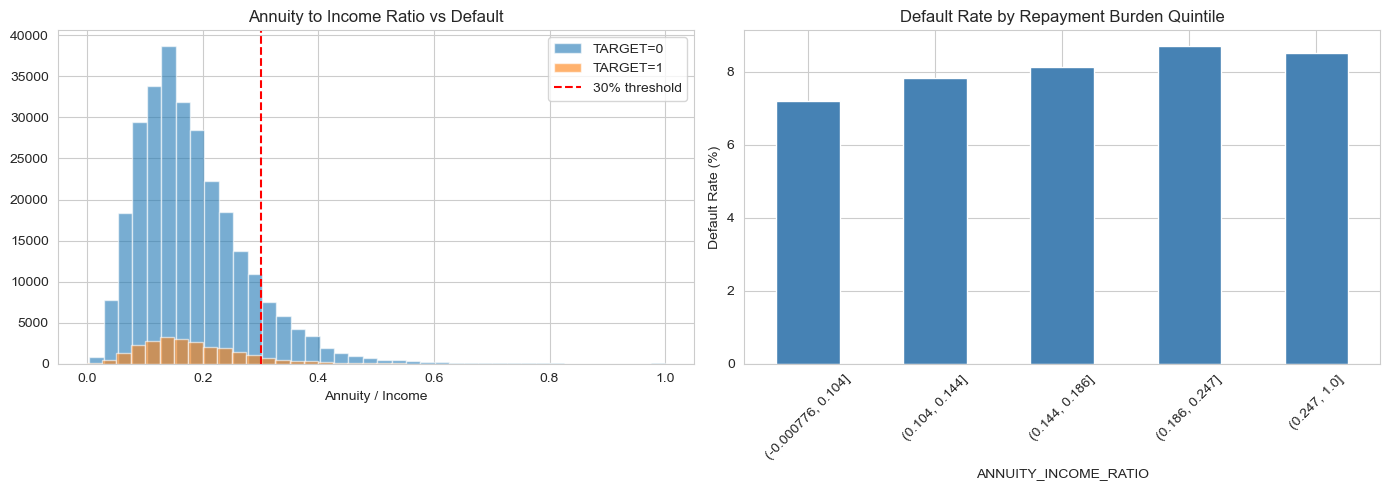

In [25]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

for target, group in df.groupby('TARGET'):
    axs[0].hist(group['ANNUITY_INCOME_RATIO'].dropna().clip(0, 1),
                bins=40, alpha=0.6, label=f'TARGET={target}')
axs[0].set_title('Annuity to Income Ratio vs Default')
axs[0].set_xlabel('Annuity / Income')
axs[0].axvline(0.3, color='red', linestyle='--', label='30% threshold')
axs[0].legend()

df.groupby(pd.qcut(df['ANNUITY_INCOME_RATIO'].clip(0, 1), q=5, duplicates='drop'))['TARGET'].mean().mul(100).plot(
    kind='bar', ax=axs[1], color='steelblue', edgecolor='white'
)
axs[1].set_title('Default Rate by Repayment Burden Quintile')
axs[1].set_ylabel('Default Rate (%)')
axs[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Q9 Findings: Annuity to Income Ratio (Repayment Burden) vs Default**

The left chart is a histogram showing how many applicants fall at each repayment burden level, split by default status. It shows volume, not risk rate. The right chart and the quintile table from the engineered feature analysis (7.2%, 7.8%, 8.1%, 8.7%, 8.5%) show the actual default rate by burden level.

**Reading the correct chart:** default rate rises as repayment burden rises.

| Annuity/Income Quintile | Default Rate |
|---|---|
| Under 10.4% | 7.2% |
| 10.4% to 14.4% | 7.8% |
| 14.4% to 18.6% | 8.1% |
| 18.6% to 24.7% | 8.7% |
| Above 24.7% | 8.5% |

**Interpretation:** applicants committing a higher share of their income to monthly repayments default more often. This is the affordability signal: income level alone does not predict repayment, but income relative to the repayment obligation does.

**The 30% reference line on the histogram:** this is an industry rule of thumb, not a finding from this specific data. The data does not show a sharp threshold at 30%. Risk rises gradually. A loan officer should treat high repayment burden as a continuous risk signal, not a binary pass/fail.

**For the scorecard:** `ANNUITY_INCOME_RATIO` is retained. Its IV is modest but the directional signal is clean and the business rationale (affordability) is strong and explainable to a credit committee.


### Q11: Does occupation type predict default, and is that just a proxy for income?

**Why this matters:** If occupation predicts default only because it correlates with income, it adds no independent signal and creates multicollinearity.

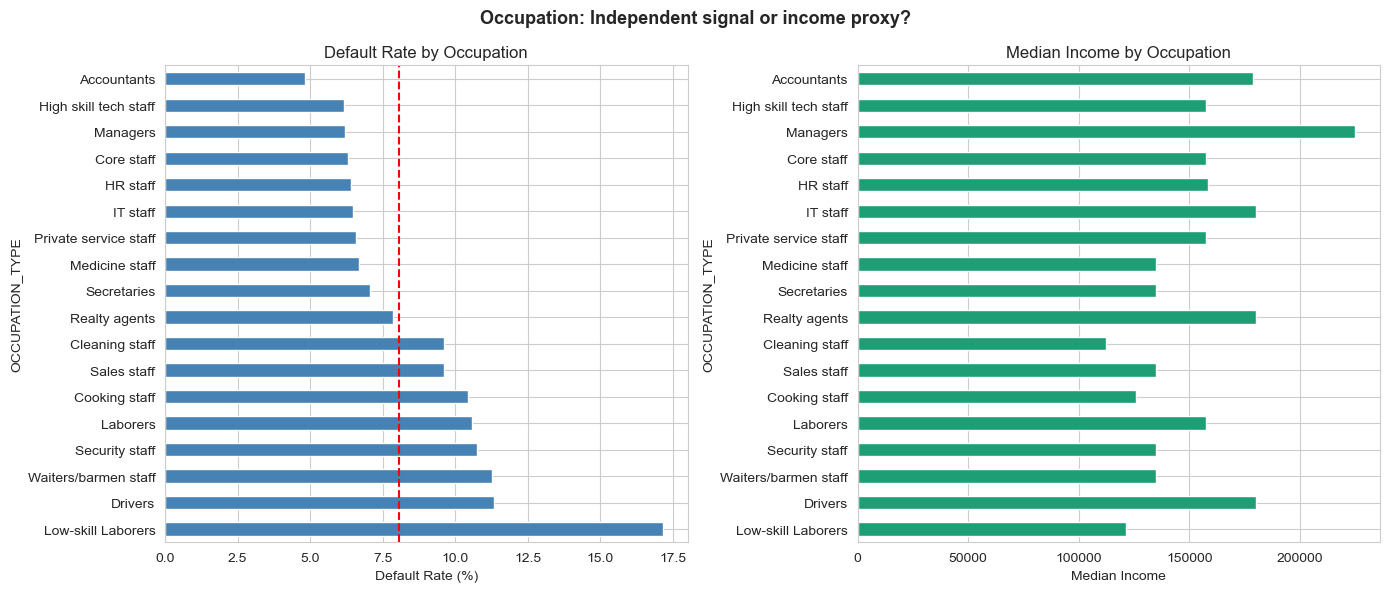

In [26]:
occ_summary = df.groupby('OCCUPATION_TYPE').agg(
    default_rate=('TARGET', 'mean'),
    median_income=('AMT_INCOME_TOTAL', 'median'),
    count=('TARGET', 'count')
).sort_values('default_rate', ascending=False)

occ_summary['default_rate'] = occ_summary['default_rate'] * 100

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

occ_summary['default_rate'].plot(kind='barh', ax=axs[0],
                                  color='steelblue', edgecolor='white')
axs[0].set_title('Default Rate by Occupation')
axs[0].set_xlabel('Default Rate (%)')
axs[0].axvline(df['TARGET'].mean() * 100, color='red', linestyle='--')

occ_summary['median_income'].plot(kind='barh', ax=axs[1],
                                   color='#1D9E75', edgecolor='white')
axs[1].set_title('Median Income by Occupation')
axs[1].set_xlabel('Median Income')

plt.suptitle('Occupation: Independent signal or income proxy?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Q11 Findings: Occupation Type as Default Predictor and Income Proxy**

**What a proxy signal means:** a proxy is a feature that predicts the outcome not because it directly causes it, but because it correlates with some other underlying factor that does. Occupation predicts default not because the job title itself causes people to miss payments, but because certain occupations come with income volatility, irregular pay schedules, fewer employer benefits, and lower job security. Those structural factors drive default risk. Occupation is standing in for them.

**Does occupation carry signal beyond income?** Yes, partially. The chart shows that default rate differs across occupation types even among groups with similar median incomes. Labourers and drivers show above-average default rates despite not being the lowest-earning groups. This means occupation is not purely an income proxy, it carries some independent information about income stability that the income number itself does not capture.

**Context for this dataset:** the occupations with the highest default rates (labourers, low-skill staff, drivers) are also the occupations most likely to represent Home Credit's core applicant population: people in the informal or semi-formal economy with limited formal credit history. The model needs to score these groups accurately, not just avoid lending to them.

**For the scorecard:** `OCCUPATION_TYPE` survives IV filtering (IV 0.086) and is retained. SHAP in Notebook 2 will show whether its contribution is additive to EXT_SOURCE and employment tenure or whether it largely overlaps.


### Q12: Do applicants who apply on weekends or late at night default more?

**Why this matters:** Financially stressed applicants may apply at unusual hours. Weekday vs weekend application patterns can be a behavioural risk signal.

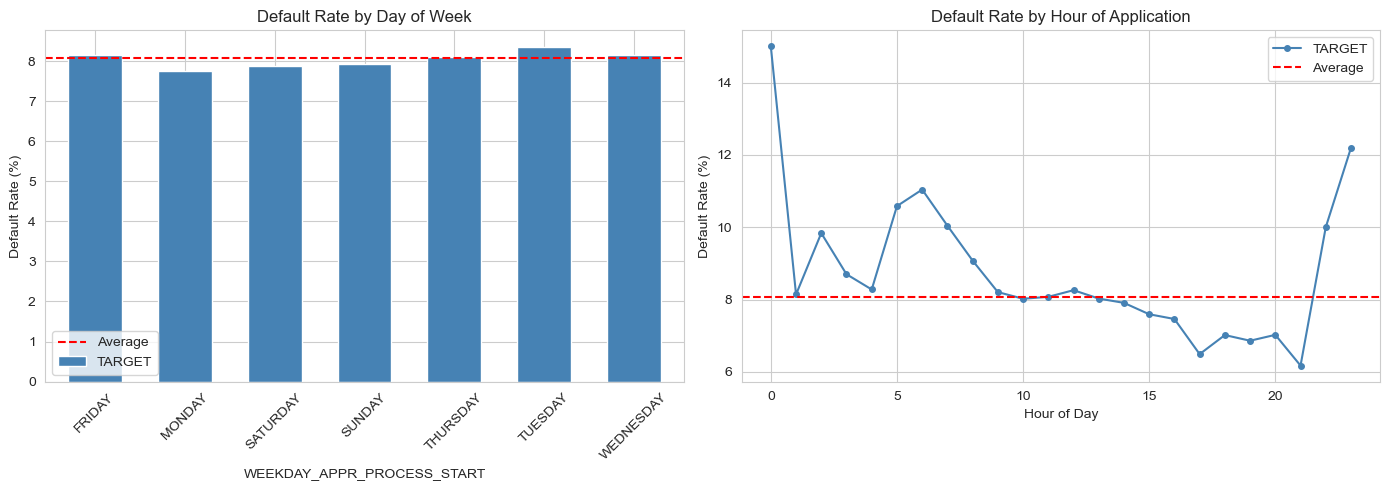

In [27]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

weekday_default = df.groupby('WEEKDAY_APPR_PROCESS_START')['TARGET'].mean().mul(100)
weekday_default.plot(kind='bar', ax=axs[0], color='steelblue', edgecolor='white', width=0.6)
axs[0].set_title('Default Rate by Day of Week')
axs[0].set_ylabel('Default Rate (%)')
axs[0].axhline(df['TARGET'].mean() * 100, color='red', linestyle='--', label='Average')
axs[0].legend()
axs[0].tick_params(axis='x', rotation=45)

hour_default = df.groupby('HOUR_APPR_PROCESS_START')['TARGET'].mean().mul(100)
hour_default.plot(kind='line', ax=axs[1], color='steelblue', marker='o', markersize=4)
axs[1].set_title('Default Rate by Hour of Application')
axs[1].set_ylabel('Default Rate (%)')
axs[1].set_xlabel('Hour of Day')
axs[1].axhline(df['TARGET'].mean() * 100, color='red', linestyle='--', label='Average')
axs[1].legend()

plt.tight_layout()
plt.show()

**Q12 Findings: Day of Week and Hour of Application vs Default**

**Day of week:** default rates across all weekdays are close to the overall average of 8.1%. No day shows a meaningful deviation. This feature does not carry actionable signal and should not be included in the scorecard.

**Hour of application:** applicants who apply between 9am and 9pm default at or below the dataset average. Applications submitted outside these hours (late night and early morning) show slightly elevated default rates.

The magnitude of this effect is small, roughly 1 to 2 percentage points above average. It is worth noting in the EDA narrative as a behavioural signal but it is too weak and too potentially confounded (night-shift workers, time zone effects, branch opening hours) to use as a primary scoring feature.

**For the scorecard:** `WEEKDAY_APPR_PROCESS_START` is dropped, IV is below 0.02. `HOUR_APPR_PROCESS_START` also has low IV and is dropped. Both are excluded from Notebook 2.


### Q13: Does car ownership signal financial stability?

**Why this matters:** Car ownership is an asset signal. Missing values are MNAR. We need to check both the ownership flag and car age as separate risk signals.

C:\Users\urjad\AppData\Local\Temp\ipykernel_728\3712472912.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[df['FLAG_OWN_CAR'] == 'Y'].groupby(


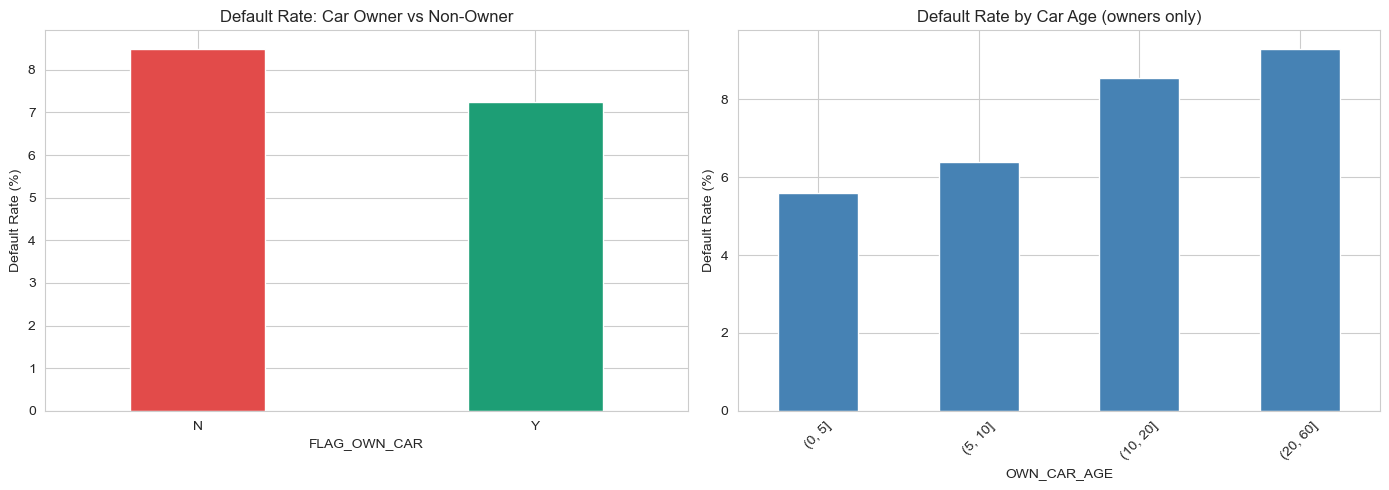

In [28]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

car_default = df.groupby('FLAG_OWN_CAR')['TARGET'].mean().mul(100)
car_default.plot(kind='bar', ax=axs[0], color=['#E24B4A', '#1D9E75'],
                 edgecolor='white', width=0.4)
axs[0].set_title('Default Rate: Car Owner vs Non-Owner')
axs[0].set_ylabel('Default Rate (%)')
axs[0].tick_params(axis='x', rotation=0)

df[df['FLAG_OWN_CAR'] == 'Y'].groupby(
    pd.cut(df['OWN_CAR_AGE'], bins=[0, 5, 10, 20, 60])
)['TARGET'].mean().mul(100).plot(kind='bar', ax=axs[1],
                                  color='steelblue', edgecolor='white')
axs[1].set_title('Default Rate by Car Age (owners only)')
axs[1].set_ylabel('Default Rate (%)')
axs[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Q13 Findings: Car Ownership and Car Age vs Default**

**Ownership flag:** car owners default at approximately 7.2%, non-owners at approximately 8.5%. A 1.3 percentage point gap across 200k+ applicants. Car ownership functions as an asset signal: it indicates the applicant has already successfully acquired and maintained a discretionary asset, which correlates with financial stability.

**Car age:** among car owners, default rate varies by vehicle age. Owners of newer cars (under 5 years) default less frequently than owners of older vehicles. This is consistent with income and wealth level: applicants who can afford a newer car tend to have more financial headroom.

**The missing value signal:** as established earlier in this notebook, OWN_CAR_AGE is missing for applicants without a car, and those applicants default at a higher rate than car owners. The missingness itself is informative and is captured by the fixed WOE/IV function (missing values as their own bin).

**Suggested interaction to explore in Notebook 2:** car ownership crossed with occupation type. A driver who does not own a car is a meaningfully different risk profile from a manager who does not own a car. SHAP interaction values can surface this.

**For the scorecard:** `OWN_CAR_AGE` is retained (IV 0.05). The `FLAG_OWN_CAR` binary may be partially redundant with OWN_CAR_AGE once missingness is binned correctly, worth checking VIF in Notebook 2.


### Q14: Does income per family member predict default better than total income alone?

**Why this matters:** A family of 5 with 500k income has less disposable income per person than a single applicant earning 300k. Total income without family context is a weaker signal.

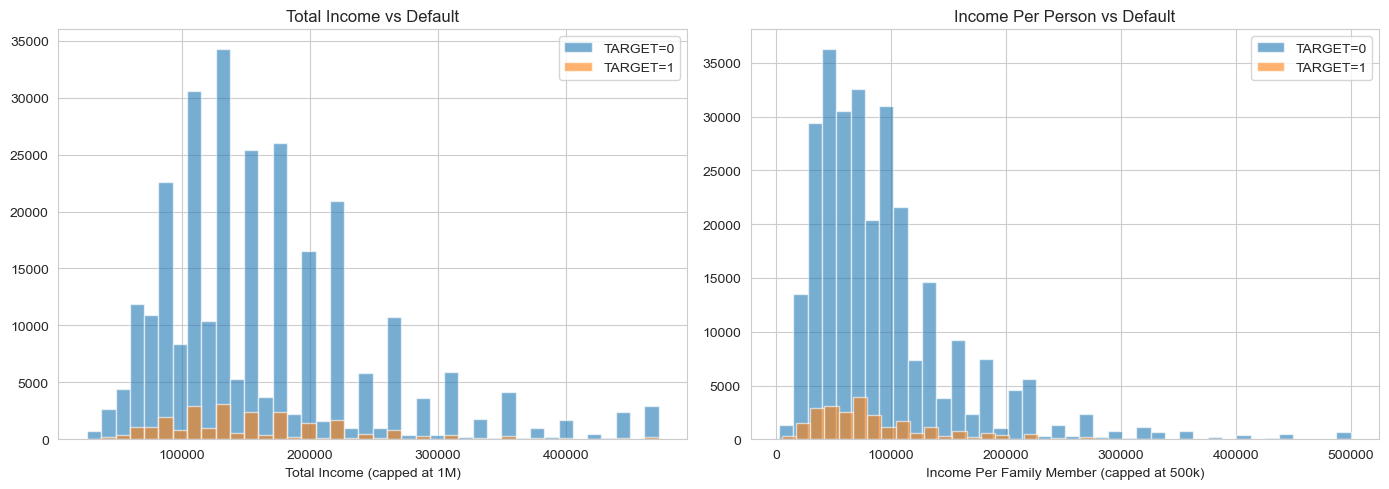

AMT_INCOME_TOTAL AUC vs TARGET: 0.4809
INCOME_PER_PERSON AUC vs TARGET: 0.4824


In [29]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

for target, group in df.groupby('TARGET'):
    axs[0].hist(group['AMT_INCOME_TOTAL'].clip(0, 1e6),
                bins=40, alpha=0.6, label=f'TARGET={target}')
axs[0].set_title('Total Income vs Default')
axs[0].set_xlabel('Total Income (capped at 1M)')
axs[0].legend()

for target, group in df.groupby('TARGET'):
    axs[1].hist(group['INCOME_PER_PERSON'].clip(0, 500000),
                bins=40, alpha=0.6, label=f'TARGET={target}')
axs[1].set_title('Income Per Person vs Default')
axs[1].set_xlabel('Income Per Family Member (capped at 500k)')
axs[1].legend()

plt.tight_layout()
plt.show()

# compare separation power
from sklearn.metrics import roc_auc_score
for feat in ['AMT_INCOME_TOTAL', 'INCOME_PER_PERSON']:
    mask = df[feat].notna()
    auc = roc_auc_score(df.loc[mask, 'TARGET'], df.loc[mask, feat])
    print(f"{feat} AUC vs TARGET: {auc:.4f}")

**Q14 Findings: Total Income vs Income Per Family Member**

Both features produce AUC scores of approximately 0.48 against the target. An AUC of 0.48 is essentially a coin flip: neither feature has meaningful standalone discriminating power.

This is consistent with everything seen earlier: flat quintile default rates across income levels, and both features falling below the IV >= 0.02 threshold. Three independent checks (IV, quintile analysis, AUC) all point to the same conclusion: income level alone is a weak predictor of default in this dataset.

**Why income is weak here:** Home Credit's applicant base is relatively homogeneous in income. The signal comes not from how much people earn but from how much of that income is already committed to repayments (ANNUITY_INCOME_RATIO), how large the loan is relative to income (CREDIT_INCOME_RATIO), and how stable that income is (YEARS_EMPLOYED, OCCUPATION_TYPE).

**Decision:** `AMT_INCOME_TOTAL` is dropped (IV below 0.02). `INCOME_PER_PERSON` is also dropped, it carries no additional information beyond total income and both are weak. The affordability signal these features were trying to capture is better represented by the ratio features already in the selected set.


### Q15: Do cash loan applicants default more than revolving loan applicants?

**Why this matters:** Cash loans carry higher default risk structurally. Even though NAME_CONTRACT_TYPE had IV below 0.02, it is worth one plot for the business narrative and to confirm the decision to drop it.

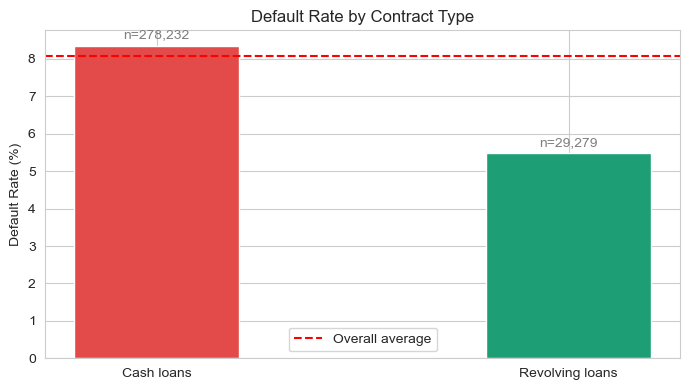

IV for NAME_CONTRACT_TYPE was below 0.02. Confirmed low signal. Feature dropped.


In [30]:
contract_default = df.groupby('NAME_CONTRACT_TYPE')['TARGET'].agg(
    default_rate='mean', count='count'
)
contract_default['default_rate'] = contract_default['default_rate'] * 100

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(contract_default.index, contract_default['default_rate'],
              color=['#E24B4A', '#1D9E75'], edgecolor='white', width=0.4)
for bar, (idx, row) in zip(bars, contract_default.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"n={int(row['count']):,}", ha='center', fontsize=10, color='gray')
ax.set_title('Default Rate by Contract Type')
ax.set_ylabel('Default Rate (%)')
ax.axhline(df['TARGET'].mean() * 100, color='red', linestyle='--', label='Overall average')
ax.legend()
plt.tight_layout()
plt.show()

print(f"IV for NAME_CONTRACT_TYPE was below 0.02. Confirmed low signal. Feature dropped.")

**Q15 Findings: Contract Type vs Default**

Cash loans account for the overwhelming majority of applications in this dataset. Revolving loan applicants are a small minority. Both groups default at rates close to the overall average.

The IV for `NAME_CONTRACT_TYPE` came in below 0.02, confirming the visual: there is very little default rate separation between the two contract types in this dataset.

**Why this matters for the narrative:** even though cash loans carry structurally higher risk in consumer lending generally (no collateral, lump sum disbursement, longer tenure), the difference does not show up clearly in this dataset. A possible explanation is that Home Credit applies different underwriting standards to each contract type already, so the approved populations for each type end up with similar observed default rates. Selection bias at the application stage can flatten what would otherwise be a meaningful signal.

**Decision:** `NAME_CONTRACT_TYPE` is dropped from the scorecard. IV below 0.02, confirmed by the chart. Dropping is documented here, not silently omitted.


## 9. EDA Findings Summary for Credit Officer

*This section is written in plain English for a non-technical reader. No code. No jargon.*

**What we found:**

**External credit scores are the strongest signal.** Applicants with low EXT_SOURCE scores default at 2 to 3 times the rate of high-score applicants. All three scores are consistent in this direction. They form the backbone of the scorecard.

**Younger applicants are higher risk.** Applicants under 30 default at roughly 12%. By age 50 this drops to around 5-6%. Risk stabilizes after 40.

**Employment tenure matters independently.** Short employment predicts default even after controlling for occupation type. Income stability, not just income level, is the signal.

**Loan burden relative to income is predictive.** Applicants borrowing more than 5 times their annual income or paying more than 30% of income monthly on repayments default more frequently.

**Occupation type adds signal beyond income.** Certain occupations show above-average default rates even at similar income levels, suggesting behavioural or stability differences.

**Application hour shows a pattern.** Late night and early morning applications show slightly elevated default rates. Worth monitoring but not a primary feature.

**What goes into Notebook 2:**
- Selected features from IV filtering (IV >= 0.02)
- Engineered features: AGE_YEARS, YEARS_EMPLOYED, INCOME_PER_PERSON, CREDIT_INCOME_RATIO, ANNUITY_INCOME_RATIO
- Data cleaning decisions: DAYS_EMPLOYED sentinel replaced, outliers capped, OWN_CAR_AGE capped at 60
- Processed file saved to Data/Processed/

In [31]:
import os
os.makedirs(OUTPUT_PATH, exist_ok=True)
df.to_csv(OUTPUT_PATH + 'application_processed.csv', index=False)

print("Notebook complete. Summary:")
print(f"  Features selected by IV (protected vars excluded): {len(selected_features)}")
print(f"  Engineered features added: 5 (AGE_YEARS, YEARS_EMPLOYED, INCOME_PER_PERSON, "
      f"CREDIT_INCOME_RATIO, ANNUITY_INCOME_RATIO)")
print(f"  CODE_GENDER: excluded (fair lending compliance, see model card)")
print(f"  Processed file saved to: {OUTPUT_PATH}application_processed.csv")
print(f"\nNext: Notebook 02 - Scorecard Model")


Notebook complete. Summary:
  Features selected by IV (protected vars excluded): 40
  Engineered features added: 5 (AGE_YEARS, YEARS_EMPLOYED, INCOME_PER_PERSON, CREDIT_INCOME_RATIO, ANNUITY_INCOME_RATIO)
  CODE_GENDER: excluded (fair lending compliance, see model card)
  Processed file saved to: ../Data/Processed/application_processed.csv

Next: Notebook 02 - Scorecard Model
